In [ ]:
# ---------------------------------------------------------------------------
# 0. Environment
# ---------------------------------------------------------------------------
import sys, subprocess, importlib

IN_COLAB = "google.colab" in sys.modules


def _ensure(module, pip_name=None):
    try:
        importlib.import_module(module)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name or module], check=True)


for _m, _p in [("segmentation_models_pytorch", "segmentation-models-pytorch"),
               ("albumentations", "albumentations"),
               ("skimage", "scikit-image"),
               ("pywt", "PyWavelets")]:
    _ensure(_m, _p)

import os, json, glob, time, math, random, warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import cv2
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

from scipy import stats
from scipy.ndimage import binary_erosion, distance_transform_edt
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score
from skimage.restoration import denoise_nl_means, estimate_sigma
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)
print(f"torch {torch.__version__} | smp {smp.__version__} | albumentations {A.__version__}")

torch 2.11.0+cu128 | smp 0.5.0 | albumentations 2.0.8


In [ ]:
# ---------------------------------------------------------------------------
# 1. Configuration and reproducibility
# ---------------------------------------------------------------------------
QUICK = os.environ.get("CERVIX_QUICK", "0") == "1"   # smoke test only

CFG = dict(
    DATA_ROOT=os.environ.get("CERVIX_ROOT", "/content/gdrive/MyDrive/cervical"),
    SPLITS=("train", "valid", "test"),
    LONG_SIDE=512,          # network input long side; short side follows the median aspect ratio
    BATCH_SIZE=8,
    EPOCHS=60,             # cosine schedule; U-Net reached 97% of its final Dice by epoch ~70 of 150
    LR=3e-4,
    WEIGHT_DECAY=1e-4,
    WARMUP_EPOCHS=3,
    PATIENCE=15,            # early stopping on validation Dice
    SEED=42,
    NUM_WORKERS=2,
    USE_CLAHE=True,         # CLAHE on the L channel before training and inference
    TTA=True,               # flip test-time augmentation
    ENCODER_WEIGHTS="imagenet",
    MODELS=["U-Net (ResNet-34)"],   # options: "U-Net", "Attention U-Net", "U-Net (ResNet-34)", "U-Net++ (ResNet-34)", "DeepLabV3+ (ResNet-34)"
    W_CE=1.0, W_DICE=1.0,
    N_BOOT=2000,
    PIXELS_PER_IMAGE=20000,  # random pixels per test image for ROC/PR curves
    RESUME=True,             # skip training if a checkpoint already exists
)
if QUICK:
    CFG.update(LONG_SIDE=128, BATCH_SIZE=4, EPOCHS=3, WARMUP_EPOCHS=1, PATIENCE=5,
               NUM_WORKERS=0, ENCODER_WEIGHTS=None, N_BOOT=200, PIXELS_PER_IMAGE=2000, RESUME=False)

CFG["OUT_DIR"] = os.path.join(CFG["DATA_ROOT"], "results_q1")
DIRS = {k: os.path.join(CFG["OUT_DIR"], k) for k in ["figures", "tables", "checkpoints", "masks", "logs"]}

if IN_COLAB and CFG["DATA_ROOT"].startswith("/content/gdrive"):
    from google.colab import drive
    drive.mount("/content/gdrive")

for d in DIRS.values():
    os.makedirs(d, exist_ok=True)


def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = False   # True is slower; set True for bit-exact reruns
    torch.backends.cudnn.benchmark = True


def seed_worker(worker_id):
    s = torch.initial_seed() % 2**32
    np.random.seed(s); random.seed(s)


seed_everything(CFG["SEED"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
print("Device:", DEVICE, "| AMP:", USE_AMP)
if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))
with open(os.path.join(DIRS["logs"], "config.json"), "w") as f:
    json.dump(CFG, f, indent=2)

Mounted at /content/gdrive
Device: cuda | AMP: True
Tesla T4


In [ ]:
# ---------------------------------------------------------------------------
# 2. Publication figure style (Elsevier artwork guidelines)
#    single column 90 mm, 1.5 column 140 mm, double column 190 mm
#    fonts 7-8 pt, embedded TrueType, 600 dpi raster, vector PDF
# ---------------------------------------------------------------------------
MM = 1 / 25.4
FIG_W = {"single": 90 * MM, "onehalf": 140 * MM, "double": 190 * MM}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],
    "font.size": 8, "axes.titlesize": 8, "axes.labelsize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "lines.linewidth": 1.2, "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "figure.dpi": 150, "savefig.dpi": 600,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42, "ps.fonttype": 42, "image.interpolation": "none",
})

# Okabe-Ito colour-blind-safe palette
OI = dict(blue="#0072B2", orange="#E69F00", green="#009E73", vermillion="#D55E00",
          purple="#CC79A7", sky="#56B4E9", yellow="#F0E442", black="#000000", grey="#7F7F7F")
MODEL_COLORS = [OI["grey"], OI["sky"], OI["blue"], OI["orange"], OI["purple"], OI["green"]]
SHORT = {"U-Net": "U-Net", "Attention U-Net": "Att. U-Net", "U-Net (ResNet-34)": "U-Net-R34",
         "U-Net++ (ResNet-34)": "U-Net++-R34", "DeepLabV3+ (ResNet-34)": "DLv3+-R34"}
SPLIT_COLORS = {"train": OI["blue"], "valid": OI["orange"], "test": OI["grey"]}


def save_figure(fig, name):
    """Write PDF (vector), 600 dpi LZW TIFF (submission) and 300 dpi PNG (preview)."""
    base = os.path.join(DIRS["figures"], name)
    fig.savefig(base + ".pdf")
    fig.savefig(base + ".tiff", dpi=600, pil_kwargs={"compression": "tiff_lzw"})
    fig.savefig(base + ".png", dpi=300)
    print("saved", base + ".{pdf,tiff,png}")


def panel_label(ax, letter, x=-0.02, y=1.02):
    ax.text(x, y, f"({letter})", transform=ax.transAxes, fontsize=8,
            fontweight="bold", va="bottom", ha="right" if x < 0 else "left")


def image_axis(ax):
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)

In [ ]:
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")


def find_annotation_file(split_dir):
    for name in ["_combined_annotations.json", "_annotations.coco.json"]:
        p = os.path.join(split_dir, name)
        if os.path.exists(p):
            return p
    js = sorted(glob.glob(os.path.join(split_dir, "*.json")))
    return js[0] if js else None


def make_unique_ids(imgs, anns, split):
    """Give every image a unique key `uid` and link annotations to it.

    Merged ("combined") COCO files often repeat image ids, because each source file
    restarts its numbering. Such files are concatenations of blocks, so a new block
    starts wherever the image id (or annotation image_id) sequence drops.
    """
    imgs = imgs.drop_duplicates(subset=["id", "file_name"]).reset_index(drop=True)
    if not imgs["id"].duplicated().any():
        imgs["uid"] = imgs["id"]; anns["uid"] = anns["image_id"]
        return _merge_same_file(imgs, anns, split)
    n_dup = int(imgs["id"].duplicated().sum())
    img_block = (imgs["id"].diff() <= 0).cumsum()
    ann_block = (anns["image_id"].diff() < 0).cumsum()
    if img_block.max() != ann_block.max():
        raise ValueError(
            f"[{split}] {n_dup} repeated image ids, and the file is not a simple concatenation "
            f"({img_block.max() + 1} image blocks vs {ann_block.max() + 1} annotation blocks). "
            "Point this split at the original Roboflow '_annotations.coco.json' instead.")
    K = 10 ** 7
    imgs["uid"] = img_block * K + imgs["id"]
    anns["uid"] = ann_block * K + anns["image_id"]
    # Sanity check: every annotation must find its image and its box must lie inside it
    dims = imgs.set_index("uid")[["width", "height"]]
    ok = anns["uid"].isin(dims.index)
    j = anns[ok].join(dims, on="uid")
    b = np.stack(j["bbox"].values)
    inside = ((b[:, 0] + b[:, 2] <= j["width"] + 2) & (b[:, 1] + b[:, 3] <= j["height"] + 2)).mean()
    print(f"[{split}] {n_dup} repeated image ids resolved into {img_block.max() + 1} blocks | "
          f"annotations matched {ok.mean():.1%} | boxes inside image {inside:.1%}")
    if ok.mean() < 0.99 or inside < 0.99:
        raise ValueError(f"[{split}] could not safely re-link annotations to images. "
                         "Use the original per-split COCO file.")
    return _merge_same_file(imgs, anns, split)


def _merge_same_file(imgs, anns, split):
    """One record per image file; exact duplicate annotations are removed."""
    first = imgs.groupby("file_name")["uid"].transform("first")
    remap = dict(zip(imgs["uid"], first))
    n_rep = int(imgs["file_name"].duplicated().sum())
    imgs = imgs.drop_duplicates("file_name").reset_index(drop=True)
    anns = anns.copy(); anns["uid"] = anns["uid"].map(remap)
    key = anns["bbox"].map(lambda b: tuple(np.round(b, 1)))
    n0 = len(anns)
    anns = anns[~pd.DataFrame({"u": anns["uid"], "c": anns["category_id"], "k": key}).duplicated()].reset_index(drop=True)
    if n_rep or n0 - len(anns):
        print(f"[{split}] merged {n_rep} repeated file entries, removed {n0 - len(anns)} duplicate annotations")
    return imgs, anns


def load_coco(split):
    split_dir = os.path.join(CFG["DATA_ROOT"], split)
    ann_file = find_annotation_file(split_dir)
    if ann_file is None:
        raise FileNotFoundError(f"No COCO json in {split_dir}")
    with open(ann_file) as f:
        coco = json.load(f)
    imgs = pd.DataFrame(coco["images"])
    anns = pd.DataFrame(coco["annotations"])
    imgs, anns = make_unique_ids(imgs, anns, split)
    imgs["path"] = imgs["file_name"].map(lambda n: os.path.join(split_dir, os.path.basename(n)))
    missing = (~imgs["path"].map(os.path.exists)).sum()
    imgs = imgs[imgs["path"].map(os.path.exists)].reset_index(drop=True)
    cats = {c["id"]: c["name"] for c in coco["categories"]}
    anns["category"] = anns["category_id"].map(cats)
    anns = anns[anns["uid"].isin(imgs["uid"])].reset_index(drop=True)
    on_disk = len([p for p in os.listdir(split_dir) if p.lower().endswith(IMG_EXT)])
    print(f"{split:5s}: {os.path.basename(ann_file)} | {len(imgs)} images in json "
          f"({missing} missing on disk, {on_disk} image files in folder) | {len(anns)} annotations")
    return imgs, anns


coco = {s: load_coco(s) for s in CFG["SPLITS"]}

# Global class list: every category that owns at least one annotation (Roboflow adds an empty super-category)
_names = sorted(set().union(*[set(a["category"].dropna()) for _, a in coco.values()]))
FG_CLASSES = sorted(_names, key=lambda n: ("abnormal" in n.lower(), n.lower()))  # Abnormal drawn last
CLASS_NAMES = ["Background"] + FG_CLASSES
NC = len(CLASS_NAMES)
CLS_IDX = {n: i for i, n in enumerate(CLASS_NAMES)}
_default_cols = [OI["green"], OI["vermillion"], OI["blue"], OI["purple"], OI["yellow"]]
CLASS_COLORS = {"Background": "#000000"}
for i, n in enumerate(FG_CLASSES):
    CLASS_COLORS[n] = OI["vermillion"] if "abnormal" in n.lower() else (
        OI["green"] if "normal" in n.lower() else _default_cols[i % len(_default_cols)])
print("Classes:", CLASS_NAMES)


def _polygons(ann):
    seg = ann.get("segmentation", None)
    polys = []
    if isinstance(seg, list) and len(seg) > 0:
        if isinstance(seg[0], (int, float)):
            seg = [seg]
        for p in seg:
            if len(p) >= 6:
                polys.append(np.round(np.asarray(p, dtype=np.float64).reshape(-1, 2)).astype(np.int32))
    if not polys:  # RLE or empty: fall back to the bounding box
        x, y, w, h = ann["bbox"]
        polys = [np.round(np.array([[x, y], [x + w, y], [x + w, y + h], [x, y + h]])).astype(np.int32)]
    return polys


def rasterize(h, w, img_anns):
    mask = np.zeros((h, w), np.uint8)
    for c in range(1, NC):                       # later classes overwrite earlier ones
        for ann in img_anns[img_anns["category"] == CLASS_NAMES[c]].to_dict("records"):
            cv2.fillPoly(mask, _polygons(ann), int(c))
    return mask


RECORDS = {}
for split, (imgs, anns) in coco.items():
    os.makedirs(os.path.join(DIRS["masks"], split), exist_ok=True)
    by_img = dict(tuple(anns.groupby("uid")))
    recs = []
    for row in tqdm(imgs.to_dict("records"), desc=f"masks {split}", leave=False):
        if "height" in row and not pd.isna(row.get("height")):
            h, w = int(row["height"]), int(row["width"])
        else:
            h, w = cv2.imread(row["path"]).shape[:2]
        stem = os.path.splitext(os.path.basename(row["path"]))[0]
        mpath = os.path.join(DIRS["masks"], split, stem + ".png")
        ia = by_img.get(row["uid"], anns.iloc[0:0])
        cv2.imwrite(mpath, rasterize(h, w, ia))   # always rebuilt (fast), so masks never go stale
        recs.append(dict(split=split, image_id=row["uid"], stem=stem, img_path=row["path"],
                         mask_path=mpath, h=h, w=w, n_ann=len(ia)))
    RECORDS[split] = recs

# Network input size: keep the median aspect ratio, both sides divisible by 32
_ar = np.median([r["w"] / r["h"] for s in RECORDS for r in RECORDS[s]])
if _ar >= 1:
    IMG_W, IMG_H = CFG["LONG_SIDE"], int(round(CFG["LONG_SIDE"] / _ar / 32) * 32)
else:
    IMG_H, IMG_W = CFG["LONG_SIDE"], int(round(CFG["LONG_SIDE"] * _ar / 32) * 32)
print(f"Median aspect ratio {_ar:.3f} -> network input {IMG_H} x {IMG_W}")

[train] merged 0 repeated file entries, removed 4233 duplicate annotations
train: _combined_annotations.json | 147 images in json (0 missing on disk, 147 image files in folder) | 4233 annotations
[valid] merged 0 repeated file entries, removed 3 duplicate annotations
valid: _annotations.coco.json | 148 images in json (0 missing on disk, 148 image files in folder) | 4582 annotations
[test] merged 0 repeated file entries, removed 1 duplicate annotations
test : _annotations.coco.json | 104 images in json (0 missing on disk, 104 image files in folder) | 2759 annotations
Classes: ['Background', 'normal', 'abnormal']


masks train:   0%|          | 0/147 [00:00<?, ?it/s]

masks valid:   0%|          | 0/148 [00:00<?, ?it/s]

masks test:   0%|          | 0/104 [00:00<?, ?it/s]

Median aspect ratio 1.349 -> network input 384 x 512


In [ ]:
inst_rows, img_rows = [], []
for split, (imgs, anns) in coco.items():
    size = imgs.set_index("uid")[["width", "height"]] if "width" in imgs else None
    for a in anns.to_dict("records"):
        if a["category"] not in FG_CLASSES:
            continue
        W, H = (size.at[a["uid"], "width"], size.at[a["uid"], "height"]) if size is not None else (np.nan, np.nan)
        bw, bh = a["bbox"][2], a["bbox"][3]
        inst_rows.append(dict(split=split, cls=a["category"], side_px=math.sqrt(bw * bh),
                              rel_area_pct=100 * bw * bh / (W * H)))
    for r in RECORDS[split]:
        m = cv2.imread(r["mask_path"], cv2.IMREAD_UNCHANGED)
        cnt = np.bincount(m.ravel(), minlength=NC)
        row = dict(split=split, stem=r["stem"], fg_pct=100 * cnt[1:].sum() / m.size)
        ia = anns[anns["uid"] == r["image_id"]]
        for c in FG_CLASSES:
            row[f"n_{c}"] = int((ia["category"] == c).sum())
            row[f"px_{c}"] = int(cnt[CLS_IDX[c]])
        row["px_Background"] = int(cnt[0])
        img_rows.append(row)
INST = pd.DataFrame(inst_rows)
IMGS = pd.DataFrame(img_rows)

# Table 1
t1 = []
for split in CFG["SPLITS"]:
    d, di = IMGS[IMGS.split == split], INST[INST.split == split]
    row = {"Split": split.capitalize(), "Images": len(d)}
    for c in FG_CLASSES:
        row[f"{c} instances"] = int(d[f"n_{c}"].sum())
    row["Instances / image"] = f"{d[[f'n_{c}' for c in FG_CLASSES]].sum(1).mean():.1f} ± {d[[f'n_{c}' for c in FG_CLASSES]].sum(1).std():.1f}"
    row["Object size, px (median)"] = f"{di.side_px.median():.0f}"
    row["Foreground, % (mean ± SD)"] = f"{d.fg_pct.mean():.2f} ± {d.fg_pct.std():.2f}"
    t1.append(row)
TABLE1 = pd.DataFrame(t1)


def to_latex_booktabs(df, caption, label, path):
    cols = list(df.columns)
    esc = lambda s: str(s).replace("%", r"\%").replace("_", r"\_").replace("±", r"$\pm$").replace("&", r"\&")
    lines = [r"\begin{table}[t]", r"\centering", rf"\caption{{{caption}}}", rf"\label{{{label}}}",
             r"\small", r"\begin{tabular}{" + "l" + "c" * (len(cols) - 1) + "}", r"\toprule",
             " & ".join(esc(c) for c in cols) + r" \\", r"\midrule"]
    lines += [" & ".join(esc(v) for v in r) + r" \\" for r in df.astype(str).values]
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    with open(path, "w") as f:
        f.write("\n".join(lines))


TABLE1.to_csv(os.path.join(DIRS["tables"], "table1_dataset.csv"), index=False)
to_latex_booktabs(TABLE1, "Composition of the Pap smear dataset.", "tab:dataset",
                  os.path.join(DIRS["tables"], "table1_dataset.tex"))
display(TABLE1) if "display" in globals() else print(TABLE1.to_string(index=False))

# Pixel-level class frequency in the training split (used for loss weights)
PIX_FREQ = np.array([IMGS[IMGS.split == "train"][f"px_{c}"].sum() for c in CLASS_NAMES], dtype=float)
PIX_FREQ /= PIX_FREQ.sum()
print("Training pixel frequency:", dict(zip(CLASS_NAMES, np.round(PIX_FREQ, 4))))

Split  Images  normal instances  abnormal instances Instances / image Object size, px (median) Foreground, % (mean ± SD)
Train     147              2725                1508       28.8 ± 22.3                       60               8.52 ± 5.60
Valid     148              2384                2198       31.0 ± 23.3                       60               7.53 ± 4.99
 Test     104              1739                1020       26.5 ± 19.3                       60               6.82 ± 4.52
Training pixel frequency: {'Background': np.float64(0.9148), 'normal': np.float64(0.0484), 'abnormal': np.float64(0.0368)}


saved /content/gdrive/MyDrive/Edward/cervical/results_q1/figures/Fig1_dataset_overview.{pdf,tiff,png}


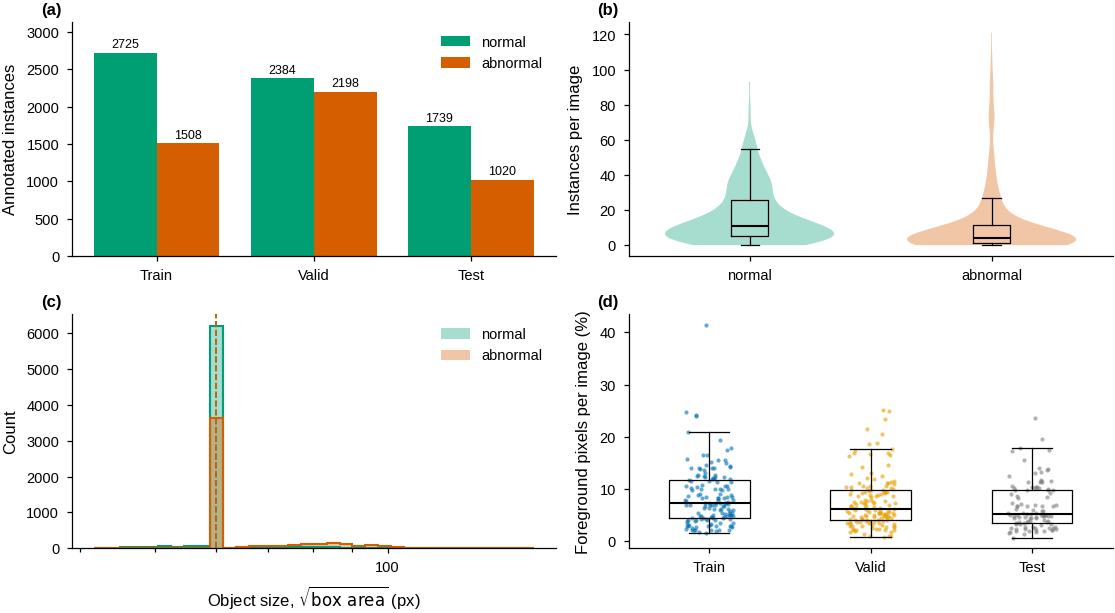

In [ ]:
# Fig. 1  Dataset overview
fig, axs = plt.subplots(2, 2, figsize=(FIG_W["double"], 105 * MM), constrained_layout=True)

ax = axs[0, 0]
xs = np.arange(len(CFG["SPLITS"])); bw = 0.8 / len(FG_CLASSES)
for k, c in enumerate(FG_CLASSES):
    vals = [IMGS[IMGS.split == s][f"n_{c}"].sum() for s in CFG["SPLITS"]]
    bars = ax.bar(xs + (k - (len(FG_CLASSES) - 1) / 2) * bw, vals, bw, color=CLASS_COLORS[c], label=c, edgecolor="none")
    ax.bar_label(bars, fontsize=6, padding=1)
ax.set_xticks(xs, [s.capitalize() for s in CFG["SPLITS"]])
ax.set_ylabel("Annotated instances"); ax.legend(loc="upper right")
ax.margins(y=0.15); panel_label(ax, "a")

ax = axs[0, 1]
data = [IMGS[f"n_{c}"].values for c in FG_CLASSES]
parts = ax.violinplot(data, showextrema=False, widths=0.7)
for b, c in zip(parts["bodies"], FG_CLASSES):
    b.set_facecolor(CLASS_COLORS[c]); b.set_alpha(0.35); b.set_edgecolor("none")
ax.boxplot(data, widths=0.15, showfliers=False, medianprops=dict(color="k", lw=1),
           boxprops=dict(lw=0.6), whiskerprops=dict(lw=0.6), capprops=dict(lw=0.6))
ax.set_xticks(range(1, len(FG_CLASSES) + 1), FG_CLASSES)
ax.set_ylabel("Instances per image"); panel_label(ax, "b")

ax = axs[1, 0]
bins = np.logspace(np.log10(max(INST.side_px.min(), 1)), np.log10(INST.side_px.max() + 1), 35)
for c in FG_CLASSES:
    ax.hist(INST[INST.cls == c].side_px, bins=bins, histtype="stepfilled", alpha=0.35, color=CLASS_COLORS[c], label=c)
    ax.hist(INST[INST.cls == c].side_px, bins=bins, histtype="step", color=CLASS_COLORS[c], lw=0.9)
    ax.axvline(INST[INST.cls == c].side_px.median(), color=CLASS_COLORS[c], ls="--", lw=0.8)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter()); ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
ax.set_xlabel(r"Object size, $\sqrt{\mathrm{box\ area}}$ (px)"); ax.set_ylabel("Count")
ax.legend(); panel_label(ax, "c")

ax = axs[1, 1]
data = [IMGS[IMGS.split == s].fg_pct.values for s in CFG["SPLITS"]]
ax.boxplot(data, widths=0.5, showfliers=False, medianprops=dict(color="k", lw=1),
           boxprops=dict(lw=0.6), whiskerprops=dict(lw=0.6), capprops=dict(lw=0.6))
rng = np.random.default_rng(0)
for i, (d, s) in enumerate(zip(data, CFG["SPLITS"])):
    ax.scatter(i + 1 + rng.uniform(-0.15, 0.15, len(d)), d, s=4, color=SPLIT_COLORS[s], alpha=0.6, lw=0)
ax.set_xticks(range(1, len(CFG["SPLITS"]) + 1), [s.capitalize() for s in CFG["SPLITS"]])
ax.set_ylabel("Foreground pixels per image (%)"); panel_label(ax, "d")
save_figure(fig, "Fig1_dataset_overview"); plt.show()

saved /content/gdrive/MyDrive/Edward/cervical/results_q1/figures/Fig2_annotated_samples.{pdf,tiff,png}


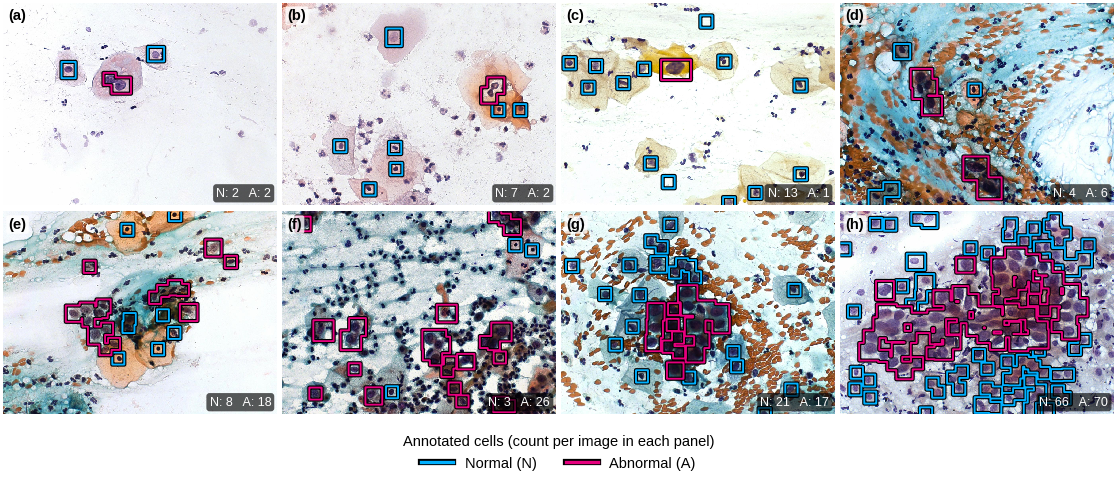

In [ ]:
# Fig. 2  Representative annotated samples (training split)


def read_rgb(path):
    return cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)


def overlay_mask(ax, img, mask, alpha=0.40, contour=True, lw=0.6):
    ax.imshow(img)
    rgba = np.zeros((*mask.shape, 4))
    for c in range(1, NC):
        col = mpl.colors.to_rgb(CLASS_COLORS[CLASS_NAMES[c]])
        rgba[mask == c] = (*col, alpha)
    ax.imshow(rgba)
    if contour:
        for c in range(1, NC):
            if (mask == c).any():
                ax.contour(mask == c, levels=[0.5], colors=[CLASS_COLORS[CLASS_NAMES[c]]], linewidths=lw)
    image_axis(ax)


def class_legend(fig, extra=None, y=-0.01, ncol=None):
    handles = [Patch(facecolor=CLASS_COLORS[c], edgecolor=CLASS_COLORS[c], alpha=0.8, label=c) for c in FG_CLASSES]
    handles += extra or []
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, y), ncol=ncol or len(handles))


# Fig. 2 layout: true-colour images, class outlines only (fill would hide the stain), 8 samples from sparse to dense
import matplotlib.patheffects as pe
VIS_CLASS = {c: ("#E6007E" if "abnormal" in c.lower() else "#00B0FF" if "normal" in c.lower() else "#FFD600")
             for c in FG_CLASSES}

def display_size(h, w, long=512):
    s_ = long / max(h, w)
    return int(round(w * s_)), int(round(h * s_))


tr = IMGS[IMGS.split == "train"].copy()
tr["both"] = (tr[[f"n_{c}" for c in FG_CLASSES]] > 0).all(1)
pool = tr[tr.both] if tr.both.sum() >= 8 else tr
pool = pool.sort_values("fg_pct").reset_index(drop=True)            # sparse -> dense
pick = pool.iloc[np.linspace(0, len(pool) - 1, 8).round().astype(int)].stem.tolist()
rec_by_stem = {r["stem"]: r for r in RECORDS["train"]}

n_r, n_c = 2, 4
aspect = np.median([rec_by_stem[s]["h"] / rec_by_stem[s]["w"] for s in pick])
Wf, left, right, wsp, hsp = FIG_W["double"], 0.005, 0.995, 0.02, 0.03
axw = (right - left) * Wf / (n_c + (n_c - 1) * wsp); axh = axw * aspect
top_in, bot_in = 0.05, 0.46
Hf = top_in + bot_in + n_r * axh + (n_r - 1) * hsp * axh
fig, axs = plt.subplots(n_r, n_c, figsize=(Wf, Hf), squeeze=False)
fig.subplots_adjust(left=left, right=right, top=1 - top_in / Hf, bottom=bot_in / Hf, wspace=wsp, hspace=hsp)

for k, (ax, stem) in enumerate(zip(axs.ravel(), pick)):
    r = rec_by_stem[stem]; dsz = display_size(r["h"], r["w"], long=1024)
    img = cv2.resize(read_rgb(r["img_path"]), dsz, interpolation=cv2.INTER_AREA)
    m = cv2.resize(cv2.imread(r["mask_path"], cv2.IMREAD_UNCHANGED), dsz, interpolation=cv2.INTER_NEAREST)
    ax.imshow(img)
    for c in FG_CLASSES:
        mc = m == CLS_IDX[c]
        if mc.any():
            cs = ax.contour(mc, levels=[0.5], colors=[VIS_CLASS[c]], linewidths=0.9)
            cs.set(path_effects=[pe.Stroke(linewidth=2.0, foreground="black"), pe.Normal()])
    image_axis(ax)
    row = tr.set_index("stem").loc[stem]
    counts = "   ".join(f"{c[0].upper()}: {int(row[f'n_{c}'])}" for c in FG_CLASSES)
    ax.text(0.98, 0.03, counts, transform=ax.transAxes, ha="right", va="bottom", fontsize=6, color="white",
            bbox=dict(boxstyle="round,pad=0.25", fc="black", ec="none", alpha=0.65))
    ax.text(0.02, 0.97, f"({'abcdefgh'[k]})", transform=ax.transAxes, ha="left", va="top", fontsize=7,
            fontweight="bold", color="black", bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8))

handles = [Line2D([0], [0], color=VIS_CLASS[c], lw=1.6, path_effects=[pe.Stroke(linewidth=3, foreground="black"), pe.Normal()],
                  label=f"{c.capitalize()} ({c[0].upper()})") for c in FG_CLASSES]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.0), ncol=len(handles), handlelength=2.2, columnspacing=2.0,
           title="Annotated cells (count per image in each panel)", title_fontsize=7)
save_figure(fig, "Fig2_annotated_samples"); plt.show()

saved /content/gdrive/MyDrive/Edward/cervical/results_q1/figures/Fig3_preprocessing.{pdf,tiff,png}


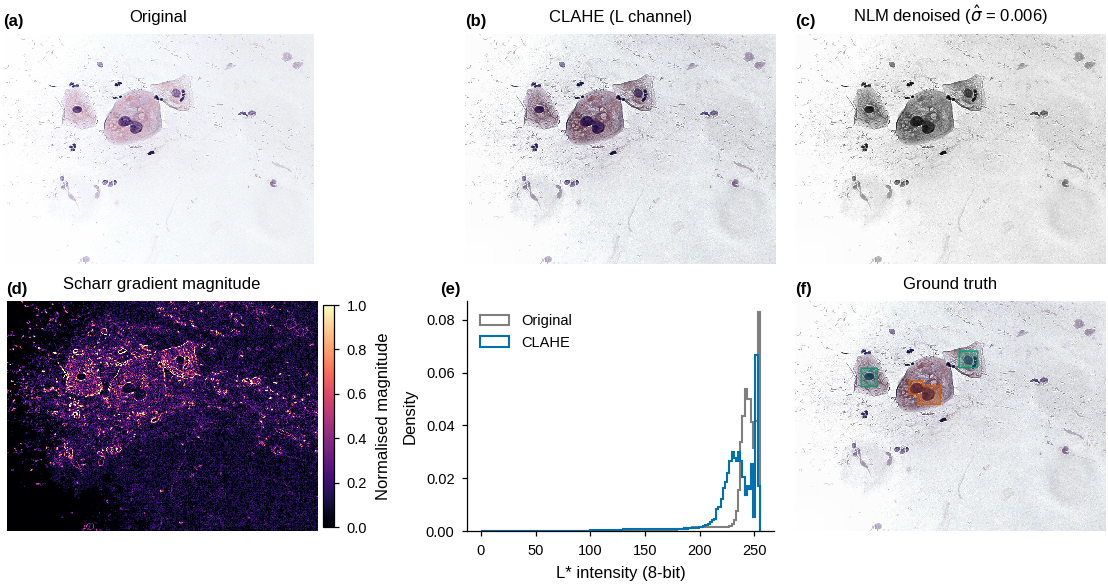

In [ ]:
def apply_clahe(rgb, clip=2.0, tiles=8):
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    lab[..., 0] = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tiles, tiles)).apply(lab[..., 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


r = rec_by_stem[pick[0]]
img0 = read_rgb(r["img_path"]); mask0 = cv2.imread(r["mask_path"], cv2.IMREAD_UNCHANGED)
img_c = apply_clahe(img0)
gray = cv2.cvtColor(img_c, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255
sigma = float(np.mean(estimate_sigma(gray)))
den = denoise_nl_means(gray, h=1.15 * sigma, sigma=sigma, fast_mode=True, patch_size=5, patch_distance=6)
gx = cv2.Scharr(den.astype(np.float32), cv2.CV_32F, 1, 0); gy = cv2.Scharr(den.astype(np.float32), cv2.CV_32F, 0, 1)
grad = np.hypot(gx, gy); grad /= np.percentile(grad, 99.5) + 1e-8

fig = plt.figure(figsize=(FIG_W["double"], 100 * MM), constrained_layout=True)
gs = fig.add_gridspec(2, 3)
ax = fig.add_subplot(gs[0, 0]); ax.imshow(img0); image_axis(ax); ax.set_title("Original"); panel_label(ax, "a", x=0)
ax = fig.add_subplot(gs[0, 1]); ax.imshow(img_c); image_axis(ax); ax.set_title("CLAHE (L channel)"); panel_label(ax, "b", x=0)
ax = fig.add_subplot(gs[0, 2]); ax.imshow(den, cmap="gray"); image_axis(ax)
ax.set_title(f"NLM denoised ($\\hat\\sigma$ = {sigma:.3f})"); panel_label(ax, "c", x=0)
ax = fig.add_subplot(gs[1, 0]); im = ax.imshow(np.clip(grad, 0, 1), cmap="magma"); image_axis(ax)
ax.set_title("Scharr gradient magnitude"); panel_label(ax, "d", x=0)
fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02, label="Normalised magnitude")
ax = fig.add_subplot(gs[1, 1])
L0 = cv2.cvtColor(img0, cv2.COLOR_RGB2LAB)[..., 0].ravel(); L1 = cv2.cvtColor(img_c, cv2.COLOR_RGB2LAB)[..., 0].ravel()
ax.hist(L0, bins=128, range=(0, 255), histtype="step", color=OI["grey"], label="Original", density=True)
ax.hist(L1, bins=128, range=(0, 255), histtype="step", color=OI["blue"], label="CLAHE", density=True)
ax.set_xlabel("L* intensity (8-bit)"); ax.set_ylabel("Density"); ax.legend(); ax.set_box_aspect(0.75)
panel_label(ax, "e")
ax = fig.add_subplot(gs[1, 2]); overlay_mask(ax, img_c, mask0, alpha=0.3); ax.set_title("Ground truth"); panel_label(ax, "f", x=0)
save_figure(fig, "Fig3_preprocessing"); plt.show()

In [ ]:
# Images are resized once when cached (see PapSegDataset), so no Resize step here
train_tf = A.Compose([
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
    A.Affine(scale=(0.9, 1.1), translate_percent=(-0.05, 0.05), rotate=(-20, 20), p=0.5),
    A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=15, val_shift_limit=10, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.1),
    A.Normalize(), ToTensorV2(),
])
eval_tf = A.Compose([A.Normalize(), ToTensorV2()])


from concurrent.futures import ThreadPoolExecutor

_CACHE = {}


def _load_resized(r, clahe):
    """Read once from Drive, CLAHE at full resolution, resize to network size."""
    img = read_rgb(r["img_path"])
    if clahe:
        img = apply_clahe(img)
    img = cv2.resize(img, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)
    mask = cv2.resize(cv2.imread(r["mask_path"], cv2.IMREAD_UNCHANGED), (IMG_W, IMG_H), interpolation=cv2.INTER_NEAREST)
    return img, mask


class PapSegDataset(Dataset):
    """Images and masks are pre-processed once and held in RAM (about 0.6 MB per image at 384 x 512)."""
    def __init__(self, records, transform, clahe=CFG["USE_CLAHE"]):
        self.records, self.transform = records, transform
        todo = [r for r in records if (r["img_path"], clahe) not in _CACHE]
        if todo:
            with ThreadPoolExecutor(8) as ex:
                for r, out in zip(todo, tqdm(ex.map(lambda r: _load_resized(r, clahe), todo), total=len(todo), desc="caching", leave=False)):
                    _CACHE[(r["img_path"], clahe)] = out
        self.items = [_CACHE[(r["img_path"], clahe)] for r in records]

    def __len__(self):
        return len(self.records)

    def __getitem__(self, i):
        img, mask = self.items[i]
        out = self.transform(image=img, mask=mask)
        return out["image"], out["mask"].long(), i


def make_loader(split, train):
    ds = PapSegDataset(RECORDS[split], train_tf if train else eval_tf)
    g = torch.Generator(); g.manual_seed(CFG["SEED"])
    return DataLoader(ds, batch_size=CFG["BATCH_SIZE"], shuffle=train, drop_last=train and len(ds) > CFG["BATCH_SIZE"],
                      num_workers=CFG["NUM_WORKERS"], pin_memory=DEVICE.type == "cuda",
                      worker_init_fn=seed_worker, generator=g, persistent_workers=CFG["NUM_WORKERS"] > 0)


loaders = {"train": make_loader("train", True), "valid": make_loader("valid", False)}
x, y, _ = next(iter(loaders["train"]))
print("batch", tuple(x.shape), tuple(y.shape), "labels present:", torch.unique(y).tolist())

caching:   0%|          | 0/147 [00:00<?, ?it/s]

caching:   0%|          | 0/148 [00:00<?, ?it/s]

batch (8, 3, 384, 512) (8, 384, 512) labels present: [0, 1, 2]


In [ ]:
class ConvBlock(nn.Sequential):
    def __init__(self, cin, cout, p_drop=0.0):
        super().__init__(
            nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
            nn.Dropout2d(p_drop) if p_drop > 0 else nn.Identity(),
            nn.Conv2d(cout, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True))


class AttentionGate(nn.Module):
    """Additive attention gate (Oktay et al., 2018)."""
    def __init__(self, f_g, f_l, f_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(f_g, f_int, 1, bias=False), nn.BatchNorm2d(f_int))
        self.W_x = nn.Sequential(nn.Conv2d(f_l, f_int, 1, bias=False), nn.BatchNorm2d(f_int))
        self.psi = nn.Sequential(nn.Conv2d(f_int, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.last_alpha = None

    def forward(self, g, x):
        a = self.psi(F.relu(self.W_g(g) + self.W_x(x), inplace=True))
        self.last_alpha = a.detach()
        return x * a


class UNet(nn.Module):
    def __init__(self, n_classes, base=32, attention=False):
        super().__init__()
        ch = [base, base * 2, base * 4, base * 8, base * 16]
        self.enc = nn.ModuleList([ConvBlock(3, ch[0])] + [ConvBlock(ch[i], ch[i + 1], 0.1 * (i >= 2)) for i in range(4)])
        self.pool = nn.MaxPool2d(2)
        self.up = nn.ModuleList([nn.ConvTranspose2d(ch[i + 1], ch[i], 2, stride=2) for i in reversed(range(4))])
        self.dec = nn.ModuleList([ConvBlock(ch[i] * 2, ch[i]) for i in reversed(range(4))])
        self.att = nn.ModuleList([AttentionGate(ch[i], ch[i], max(ch[i] // 2, 8)) for i in reversed(range(4))]) if attention else None
        self.head = nn.Conv2d(ch[0], n_classes, 1)

    def forward(self, x):
        skips = []
        for i, blk in enumerate(self.enc):
            x = blk(x if i == 0 else self.pool(x))
            skips.append(x)
        x = skips.pop()
        for k, (up, dec) in enumerate(zip(self.up, self.dec)):
            x = up(x)
            s = skips.pop()
            if self.att is not None:
                s = self.att[k](x, s)
            x = dec(torch.cat([x, s], 1))
        return self.head(x)


def build_model(name):
    w = CFG["ENCODER_WEIGHTS"]
    if name == "U-Net":
        return UNet(NC, attention=False)
    if name == "Attention U-Net":
        return UNet(NC, attention=True)
    if name == "U-Net (ResNet-34)":
        return smp.Unet("resnet34", encoder_weights=w, in_channels=3, classes=NC)
    if name == "U-Net++ (ResNet-34)":
        return smp.UnetPlusPlus("resnet34", encoder_weights=w, in_channels=3, classes=NC)
    if name == "DeepLabV3+ (ResNet-34)":
        return smp.DeepLabV3Plus("resnet34", encoder_weights=w, in_channels=3, classes=NC)
    raise ValueError(name)


def count_params(m):
    return sum(p.numel() for p in m.parameters()) / 1e6


for n in CFG["MODELS"]:
    m = build_model(n)
    with torch.no_grad():
        out = m.eval()(torch.zeros(1, 3, IMG_H, IMG_W))
    print(f"{n:25s} params {count_params(m):6.2f} M  output {tuple(out.shape)}")
del m

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

U-Net (ResNet-34)         params  24.44 M  output (1, 3, 384, 512)


In [ ]:
CE_W = 1 / np.sqrt(PIX_FREQ + 1e-8); CE_W = np.minimum(CE_W / CE_W.mean(), 10.0)
print("CE weights:", dict(zip(CLASS_NAMES, np.round(CE_W, 3))))


class DiceCELoss(nn.Module):
    def __init__(self, n_classes, ce_weight, w_ce=1.0, w_dice=1.0, smooth=1.0):
        super().__init__()
        self.n, self.w_ce, self.w_dice, self.smooth = n_classes, w_ce, w_dice, smooth
        self.register_buffer("ce_weight", torch.tensor(ce_weight, dtype=torch.float32))

    def forward(self, logits, target):
        logits = logits.float()
        ce = F.cross_entropy(logits, target, weight=self.ce_weight)
        prob = logits.softmax(1)
        oh = F.one_hot(target, self.n).permute(0, 3, 1, 2).float()
        inter = (prob * oh).sum((0, 2, 3)); card = prob.sum((0, 2, 3)) + oh.sum((0, 2, 3))
        dice = (2 * inter + self.smooth) / (card + self.smooth)
        return self.w_ce * ce + self.w_dice * (1 - dice[1:].mean())


def confusion(pred, gt, n=NC):
    return np.bincount(n * gt.ravel().astype(np.int64) + pred.ravel(), minlength=n * n).reshape(n, n)


def _safe(a, b):
    return a / b if b > 0 else np.nan


def metrics_from_cm(cm, c):
    tp = cm[c, c]; fp = cm[:, c].sum() - tp; fn = cm[c, :].sum() - tp; tn = cm.sum() - tp - fp - fn
    return dict(Dice=_safe(2 * tp, 2 * tp + fp + fn), IoU=_safe(tp, tp + fp + fn), Precision=_safe(tp, tp + fp),
                Recall=_safe(tp, tp + fn), Specificity=_safe(tn, tn + fp))


def binary_metrics(pred, gt):
    tp = np.sum(pred & gt); fp = np.sum(pred & ~gt); fn = np.sum(~pred & gt); tn = np.sum(~pred & ~gt)
    return dict(Dice=_safe(2 * tp, 2 * tp + fp + fn), IoU=_safe(tp, tp + fp + fn), Precision=_safe(tp, tp + fp),
                Recall=_safe(tp, tp + fn), Specificity=_safe(tn, tn + fp), Accuracy=(tp + tn) / pred.size)


def hd95(pred, gt):
    if not pred.any() and not gt.any():
        return 0.0
    if not pred.any() or not gt.any():
        return np.nan
    pb = pred ^ binary_erosion(pred); gb = gt ^ binary_erosion(gt)
    d = np.concatenate([distance_transform_edt(~gb)[pb], distance_transform_edt(~pb)[gb]])
    return float(np.percentile(d, 95))


def lr_lambda(ep):
    if ep < CFG["WARMUP_EPOCHS"]:
        return (ep + 1) / CFG["WARMUP_EPOCHS"]
    t = (ep - CFG["WARMUP_EPOCHS"]) / max(1, CFG["EPOCHS"] - CFG["WARMUP_EPOCHS"])
    return 0.01 + 0.99 * 0.5 * (1 + math.cos(math.pi * t))


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval(); cm = np.zeros((NC, NC), np.int64); loss = 0.0
    for x, y, _ in loader:
        x, y = x.to(DEVICE, non_blocking=True, memory_format=torch.channels_last), y.to(DEVICE, non_blocking=True)
        with torch.autocast(DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            logits = model(x)
        loss += criterion(logits, y).item() * x.size(0)
        cm += confusion(logits.argmax(1).cpu().numpy(), y.cpu().numpy())
    dices = [metrics_from_cm(cm, c)["Dice"] for c in range(1, NC)]
    return loss / len(loader.dataset), float(np.nanmean(dices)), dices


def slug(name):
    return "".join(ch if ch.isalnum() else "_" for ch in name).strip("_")


def _atomic_save(obj, path):
    tmp = path + ".tmp"
    torch.save(obj, tmp)
    os.replace(tmp, path)   # a disconnect mid-write never corrupts the checkpoint


def train_model(name):
    ckpt = os.path.join(DIRS["checkpoints"], slug(name) + ".pt")            # best on validation
    last = os.path.join(DIRS["checkpoints"], slug(name) + "_last.pt")       # resume point, every epoch
    hist_path = os.path.join(DIRS["logs"], slug(name) + "_history.csv")
    done_flag = os.path.join(DIRS["checkpoints"], slug(name) + ".done")
    if CFG["RESUME"] and os.path.exists(done_flag) and os.path.exists(ckpt):
        print(f"[{name}] training already finished")
        return pd.read_csv(hist_path)
    seed_everything(CFG["SEED"])
    model = build_model(name).to(DEVICE, memory_format=torch.channels_last)
    criterion = DiceCELoss(NC, CE_W, CFG["W_CE"], CFG["W_DICE"]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG["LR"], weight_decay=CFG["WEIGHT_DECAY"])
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_AMP)
    start_ep, best, wait, hist, elapsed = 0, -1.0, 0, [], 0.0
    if CFG["RESUME"] and os.path.exists(last):
        st = torch.load(last, map_location=DEVICE, weights_only=False)
        model.load_state_dict(st["model"]); opt.load_state_dict(st["opt"])
        sched.load_state_dict(st["sched"]); scaler.load_state_dict(st["scaler"])
        start_ep, best, wait, hist, elapsed = st["epoch"], st["best"], st["wait"], st["hist"], st["elapsed"]
        torch.set_rng_state(st["rng_torch"]); np.random.set_state(st["rng_np"]); random.setstate(st["rng_py"])
        if DEVICE.type == "cuda" and st.get("rng_cuda") is not None:
            torch.cuda.set_rng_state_all(st["rng_cuda"])
        print(f"[{name}] resumed after epoch {start_ep} (best val Dice {best:.4f})")
    t0 = time.time()
    for ep in range(start_ep, CFG["EPOCHS"]):
        if wait >= CFG["PATIENCE"]:
            break
        model.train(); run = 0.0
        for x, y, _ in loaders["train"]:
            x, y = x.to(DEVICE, non_blocking=True, memory_format=torch.channels_last), y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
                loss = criterion(model(x), y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            run += loss.item() * x.size(0)
        sched.step()
        tr_loss = run / (len(loaders["train"]) * CFG["BATCH_SIZE"]) if loaders["train"].drop_last else run / len(loaders["train"].dataset)
        va_loss, va_dice, va_cls = validate(model, loaders["valid"], criterion)
        hist.append(dict(epoch=ep + 1, train_loss=tr_loss, val_loss=va_loss, val_dice=va_dice,
                         lr=opt.param_groups[0]["lr"], **{f"val_dice_{c}": d for c, d in zip(FG_CLASSES, va_cls)}))
        improved = va_dice > best + 1e-4
        if improved:
            best, wait = va_dice, 0
            _atomic_save({"model": model.state_dict(), "epoch": ep + 1, "val_dice": va_dice, "cfg": CFG}, ckpt)
        else:
            wait += 1
        _atomic_save({"model": model.state_dict(), "opt": opt.state_dict(), "sched": sched.state_dict(),
                      "scaler": scaler.state_dict(), "epoch": ep + 1, "best": best, "wait": wait, "hist": hist,
                      "elapsed": elapsed + time.time() - t0, "rng_torch": torch.get_rng_state(),
                      "rng_np": np.random.get_state(), "rng_py": random.getstate(),
                      "rng_cuda": torch.cuda.get_rng_state_all() if DEVICE.type == "cuda" else None}, last)
        pd.DataFrame(hist).to_csv(hist_path, index=False)
        print(f"[{name}] ep {ep + 1:3d} | train {tr_loss:.4f} | val {va_loss:.4f} | val Dice {va_dice:.4f}"
              f"{' *' if improved else ''}")
        if wait >= CFG["PATIENCE"]:
            print(f"[{name}] early stop at epoch {ep + 1}")
    h = pd.DataFrame(hist); h["train_time_min"] = (elapsed + time.time() - t0) / 60
    h.to_csv(hist_path, index=False)
    open(done_flag, "w").write(str(len(h)))
    del model; torch.cuda.empty_cache()
    return h

CE weights: {'Background': np.float64(0.29), 'normal': np.float64(1.262), 'abnormal': np.float64(1.448)}


In [ ]:
HISTORY = {name: train_model(name) for name in CFG["MODELS"]}

[U-Net (ResNet-34)] training already finished


In [ ]:
def load_best(name):
    m = build_model(name).to(DEVICE)
    ck = torch.load(os.path.join(DIRS["checkpoints"], slug(name) + ".pt"), map_location=DEVICE, weights_only=False)
    m.load_state_dict(ck["model"]); m.eval()
    return m, ck["epoch"]


@torch.no_grad()
def predict_probs(model, x, out_hw):
    with torch.autocast(DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
        p = model(x).float().softmax(1)
        if CFG["TTA"]:
            p = p + model(x.flip(-1)).float().softmax(1).flip(-1)
            p = p + model(x.flip(-2)).float().softmax(1).flip(-2)
            p = p / 3
    return F.interpolate(p, size=out_hw, mode="bilinear", align_corners=False)[0].cpu().numpy()


def display_size(h, w, long=512):
    s = long / max(h, w)
    return int(round(w * s)), int(round(h * s))


test_ds = PapSegDataset(RECORDS["test"], eval_tf)
rng = np.random.default_rng(CFG["SEED"])
ROWS, CMS, PIX, PRED_SMALL, PROB_SMALL, BEST_EPOCH = [], {}, {}, {}, {}, {}
for name in CFG["MODELS"]:
    model, BEST_EPOCH[name] = load_best(name)
    cm_tot = np.zeros((NC, NC), np.int64); pix_p, pix_y = [], []
    PRED_SMALL[name], PROB_SMALL[name] = {}, {}
    for i in tqdm(range(len(test_ds)), desc=name, leave=False):
        x, _, _ = test_ds[i]; r = RECORDS["test"][i]
        gt = cv2.imread(r["mask_path"], cv2.IMREAD_UNCHANGED)
        prob = predict_probs(model, x[None].to(DEVICE), gt.shape)
        pred = prob.argmax(0).astype(np.uint8)
        cm = confusion(pred, gt); cm_tot += cm
        row = dict(model=name, image=r["stem"])
        for c in range(1, NC):
            for k, v in metrics_from_cm(cm, c).items():
                row[f"{k}_{CLASS_NAMES[c]}"] = v
        for k, v in binary_metrics(pred > 0, gt > 0).items():
            row[f"{k}_FG"] = v
        row["HD95_FG"] = hd95(pred > 0, gt > 0)
        ROWS.append(row)
        idx = rng.choice(gt.size, size=min(CFG["PIXELS_PER_IMAGE"], gt.size), replace=False)
        pix_p.append(prob.reshape(NC, -1)[:, idx].T.astype(np.float16)); pix_y.append(gt.ravel()[idx])
        dsz = display_size(*gt.shape)
        PRED_SMALL[name][r["stem"]] = cv2.resize(pred, dsz, interpolation=cv2.INTER_NEAREST)
        PROB_SMALL[name][r["stem"]] = np.stack([cv2.resize(prob[c], dsz, interpolation=cv2.INTER_AREA) for c in range(NC)])
    CMS[name] = cm_tot
    PIX[name] = (np.concatenate(pix_p).astype(np.float32), np.concatenate(pix_y))
    del model; torch.cuda.empty_cache()

PER_IMAGE = pd.DataFrame(ROWS)
PER_IMAGE.to_csv(os.path.join(DIRS["tables"], "per_image_test_metrics.csv"), index=False)
print(PER_IMAGE.groupby("model")[["Dice_FG", "IoU_FG", "HD95_FG"]].mean().round(4))

caching:   0%|          | 0/104 [00:00<?, ?it/s]

U-Net (ResNet-34):   0%|          | 0/104 [00:00<?, ?it/s]

                   Dice_FG  IoU_FG  HD95_FG
model                                      
U-Net (ResNet-34)   0.7584  0.6159  90.4703


In [ ]:
# Computational cost: parameters, GFLOPs (one forward pass), latency (batch 1, no TTA)
from torch.utils.flop_counter import FlopCounterMode

COST = []
for name in CFG["MODELS"]:
    m = build_model(name).to(DEVICE).eval()
    x = torch.randn(1, 3, IMG_H, IMG_W, device=DEVICE)
    with torch.no_grad():
        fc = FlopCounterMode(display=False)
        with fc:
            m(x)
        gflops = fc.get_total_flops() / 1e9
        for _ in range(5):
            m(x)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        reps = 30 if not QUICK else 3
        t = time.perf_counter()
        for _ in range(reps):
            m(x)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        ms = (time.perf_counter() - t) / reps * 1000
    COST.append(dict(model=name, params_M=count_params(m), GFLOPs=gflops, latency_ms=ms,
                     best_epoch=BEST_EPOCH[name], train_time_min=HISTORY[name]["train_time_min"].iloc[0]))
    del m
COST = pd.DataFrame(COST)
print(COST.round(2).to_string(index=False))

            model  params_M  GFLOPs  latency_ms  best_epoch  train_time_min
U-Net (ResNet-34)     24.44    47.0       12.97          48            6.32


In [ ]:
def mean_sd(s, pct=True, dec=2):
    s = s.dropna(); f = 100 if pct else 1
    return f"{f * s.mean():.{dec}f} ± {f * s.std():.{dec}f}" if len(s) else "n/a"


def boot_ci(v, n=CFG["N_BOOT"], seed=CFG["SEED"]):
    v = np.asarray(v, float); v = v[~np.isnan(v)]
    if len(v) == 0:
        return (np.nan, np.nan)
    r = np.random.default_rng(seed)
    means = v[r.integers(0, len(v), (n, len(v)))].mean(1)
    return tuple(np.percentile(means, [2.5, 97.5]))


summary = []
for name in CFG["MODELS"]:
    d = PER_IMAGE[PER_IMAGE.model == name]
    lo, hi = boot_ci(d["Dice_FG"])
    row = {"Model": name}
    for c in FG_CLASSES:
        row[f"Dice {c} (%)"] = mean_sd(d[f"Dice_{c}"])
    row["Dice FG (%)"] = mean_sd(d["Dice_FG"])
    row["95% CI"] = f"[{100 * lo:.2f}, {100 * hi:.2f}]"
    row["IoU FG (%)"] = mean_sd(d["IoU_FG"])
    row["Precision (%)"] = mean_sd(d["Precision_FG"])
    row["Recall (%)"] = mean_sd(d["Recall_FG"])
    row["Specificity (%)"] = mean_sd(d["Specificity_FG"])
    row["HD95 (px)"] = mean_sd(d["HD95_FG"], pct=False, dec=1)
    summary.append(row)
TABLE2 = pd.DataFrame(summary)

means = PER_IMAGE.groupby("model")["Dice_FG"].mean()
BEST = means.idxmax()
tests = []
for name in (CFG["MODELS"] if len(CFG["MODELS"]) > 1 else []):
    if name == BEST:
        continue
    a = PER_IMAGE[PER_IMAGE.model == BEST].set_index("image")["Dice_FG"]
    b = PER_IMAGE[PER_IMAGE.model == name].set_index("image")["Dice_FG"]
    j = pd.concat([a, b], axis=1, keys=["a", "b"]).dropna()
    try:
        p = stats.wilcoxon(j["a"], j["b"]).pvalue
    except ValueError:
        p = 1.0
    diff = j["a"] - j["b"]
    tests.append(dict(Comparison=f"{BEST} vs {name}", n=len(j), **{"Mean ΔDice (pp)": f"{100 * diff.mean():+.2f}"}, p_raw=p))
TABLE3 = pd.DataFrame(tests)
if len(TABLE3):
    order = np.argsort(TABLE3.p_raw.values); m = len(order); adj = np.empty(m); run = 0
    for rank, k in enumerate(order):
        run = max(run, min(1.0, (m - rank) * TABLE3.p_raw.values[k])); adj[k] = run
    TABLE3["p (Holm)"] = adj
    TABLE3["Significant (α = 0.05)"] = np.where(adj < 0.05, "Yes", "No")
    TABLE3["p (raw)"] = TABLE3.p_raw.map(lambda v: f"{v:.2e}")
    TABLE3["p (Holm)"] = TABLE3["p (Holm)"].map(lambda v: f"{v:.2e}")
    TABLE3 = TABLE3.drop(columns="p_raw")

TABLE4 = COST.rename(columns={"model": "Model", "params_M": "Params (M)", "GFLOPs": "GFLOPs",
                              "latency_ms": "Latency (ms)", "best_epoch": "Best epoch",
                              "train_time_min": "Training time (min)"}).round(2)

for t, n, cap, lab in [x for x in [(TABLE2, "table2_test_results", f"Test-set segmentation performance (n = {len(RECORDS['test'])} images). Values are mean $\\pm$ SD over images.", "tab:results"),
                       (TABLE3, "table3_wilcoxon", "Paired Wilcoxon signed-rank tests on per-image foreground Dice.", "tab:stats"),
                       (TABLE4, "table4_cost", f"Computational cost at {IMG_H} $\\times$ {IMG_W} input.", "tab:cost")] if len(x[0])]:
    t.to_csv(os.path.join(DIRS["tables"], n + ".csv"), index=False)
    to_latex_booktabs(t, cap, lab, os.path.join(DIRS["tables"], n + ".tex"))
    display(t) if "display" in globals() else print(t.to_string(index=False))
print("Best model:", BEST)

            Model Dice normal (%) Dice abnormal (%)  Dice FG (%)         95% CI   IoU FG (%) Precision (%)    Recall (%) Specificity (%)    HD95 (px)
U-Net (ResNet-34)   67.28 ± 20.14     64.67 ± 20.66 75.84 ± 7.45 [74.41, 77.21] 61.59 ± 8.54  66.99 ± 8.03 88.99 ± 10.61    96.81 ± 2.41 90.5 ± 107.1
            Model  Params (M)  GFLOPs  Latency (ms)  Best epoch  Training time (min)
U-Net (ResNet-34)       24.44    47.0         12.97          48                 6.32
Best model: U-Net (ResNet-34)


saved /content/gdrive/MyDrive/Edward/cervical/results_q1/figures/Fig4_learning_curves.{pdf,tiff,png}


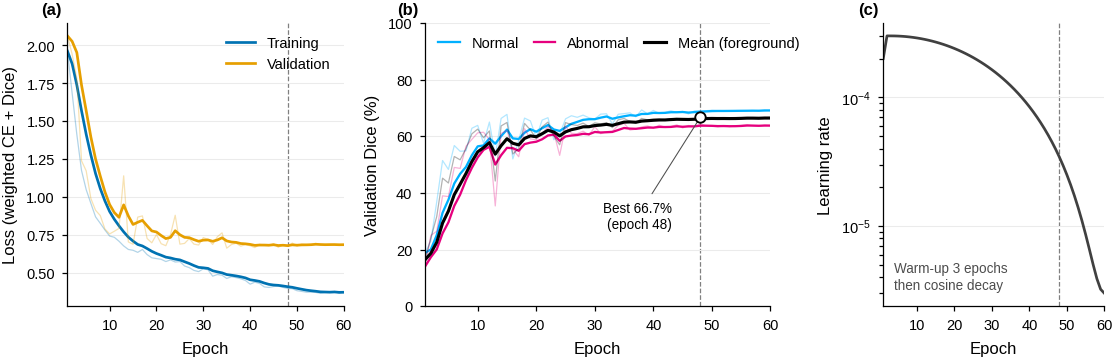

In [ ]:
# Fig. 4  Learning curves of the selected model (raw values faint, smoothed lines on top)
h = HISTORY[BEST if "BEST" in globals() else CFG["MODELS"][0]].copy()
VIS_CLASS = globals().get("VIS_CLASS") or {c: ("#E6007E" if "abnormal" in c.lower() else "#00B0FF") for c in FG_CLASSES}
C_TRAIN, C_VAL, C_MEAN = "#0072B2", "#E69F00", "#000000"


def ema(x, a=0.3):
    return pd.Series(x).ewm(alpha=a, adjust=False).mean().values


def series(ax, x, y, col, label, ls="-", lw=1.3):
    ax.plot(x, y, color=col, lw=0.6, alpha=0.30, ls=ls)
    ax.plot(x, ema(y), color=col, lw=lw, ls=ls, label=label)


best_i = h.val_dice.idxmax(); best_ep = int(h.epoch[best_i]); best_d = 100 * h.val_dice[best_i]
fig, axs = plt.subplots(1, 3, figsize=(FIG_W["double"], 62 * MM), constrained_layout=True,
                        gridspec_kw=dict(width_ratios=[1, 1.25, 0.8]))

ax = axs[0]
series(ax, h.epoch, h.train_loss, C_TRAIN, "Training")
series(ax, h.epoch, h.val_loss, C_VAL, "Validation")
ax.set(xlabel="Epoch", ylabel="Loss (weighted CE + Dice)")
ax.legend(loc="upper right")

ax = axs[1]
for c in FG_CLASSES:
    col_ = f"val_dice_{c}"
    if col_ in h:
        series(ax, h.epoch, 100 * h[col_], VIS_CLASS[c], c.capitalize(), lw=1.1)
series(ax, h.epoch, 100 * h.val_dice, C_MEAN, "Mean (foreground)", lw=1.5)
ax.plot(best_ep, best_d, "o", ms=5, mfc="white", mec="black", mew=0.9, zorder=5)
ax.annotate(f"Best {best_d:.1f}%\n(epoch {best_ep})", (best_ep, best_d),
            xytext=(best_ep - 0.08 * h.epoch.max(), max(best_d - 35, 8)), textcoords="data",
            ha="right", va="center", fontsize=6.5,
            arrowprops=dict(arrowstyle="-", lw=0.5, color="0.3"))
ax.set(xlabel="Epoch", ylabel="Validation Dice (%)", ylim=(0, 100))
ax.legend(loc="upper left", ncol=3, columnspacing=1.0, handlelength=1.5)

ax = axs[2]
ax.plot(h.epoch, h.lr, color="0.25", lw=1.3)
ax.set_yscale("log"); ax.set(xlabel="Epoch", ylabel="Learning rate")
ax.text(0.05, 0.05, f"Warm-up {CFG['WARMUP_EPOCHS']} epochs\nthen cosine decay", transform=ax.transAxes,
        ha="left", va="bottom", fontsize=6.5, color="0.3")

for ax, L in zip(axs, "abc"):
    ax.axvline(best_ep, color="0.5", ls="--", lw=0.6, zorder=0)
    ax.set_xlim(1, h.epoch.max())
    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True, nbins=6))
    ax.grid(axis="y", color="0.92", lw=0.5); ax.set_axisbelow(True)
    panel_label(ax, L)
save_figure(fig, "Fig4_learning_curves"); plt.show()

saved /content/gdrive/MyDrive/Edward/cervical/results_q1/figures/Fig5_dice_distributions.{pdf,tiff,png}


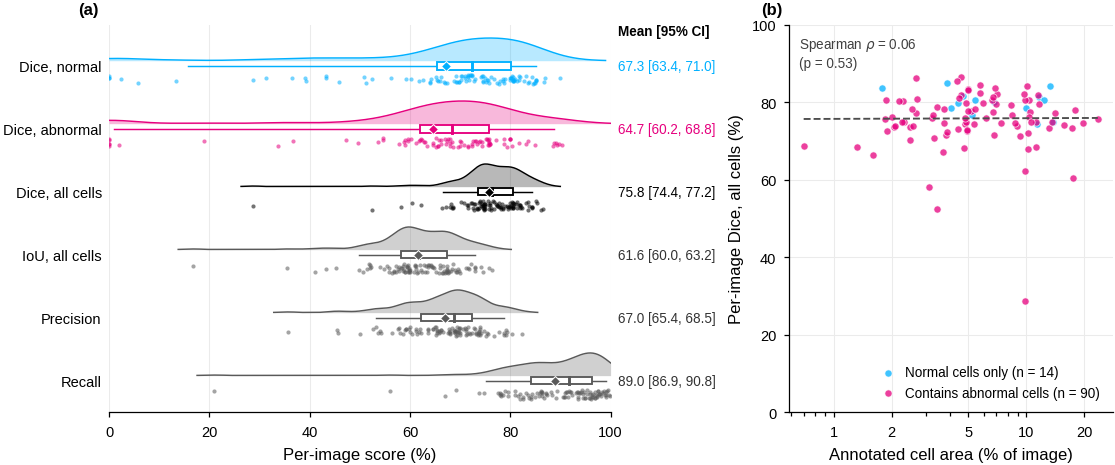

In [ ]:
# Fig. 5  Per-image test performance: (a) raincloud of metrics, (b) Dice versus cell density
from scipy.stats import gaussian_kde, spearmanr
VIS_CLASS = globals().get("VIS_CLASS") or {c: ("#E6007E" if "abnormal" in c.lower() else "#00B0FF") for c in FG_CLASSES}
d5 = PER_IMAGE[PER_IMAGE.model == BEST].copy()
metrics = [(f"Dice_{c}", f"Dice, {c.lower()}", VIS_CLASS[c]) for c in FG_CLASSES]
metrics += [("Dice_FG", "Dice, all cells", "#000000"), ("IoU_FG", "IoU, all cells", "0.35"),
            ("Precision_FG", "Precision", "0.35"), ("Recall_FG", "Recall", "0.35")]
metrics = metrics[::-1]                                     # first metric at the top
rng = np.random.default_rng(1)

fig = plt.figure(figsize=(FIG_W["double"], 80 * MM), constrained_layout=True)
gs = fig.add_gridspec(1, 2, width_ratios=[1.55, 1])
ax = fig.add_subplot(gs[0])
for i, (col, lab, c) in enumerate(metrics):
    v = 100 * d5[col].dropna().values
    if len(v) == 0:
        continue
    if len(v) > 2 and v.std() > 0:                          # half violin above the row
        xs = np.linspace(0, 100, 400); k = gaussian_kde(v, bw_method=0.25)(xs)
        keep = k >= 0.01 * k.max(); xs, k = xs[keep], k[keep]          # draw only where there is data
        ax.fill_between(xs, i + 0.08, i + 0.08 + 0.36 * k / k.max(), color=c, alpha=0.28, lw=0)
        ax.plot(xs, i + 0.08 + 0.36 * k / k.max(), color=c, lw=0.7)
    q1, med, q3 = np.percentile(v, [25, 50, 75])
    ax.add_patch(mpl.patches.Rectangle((q1, i - 0.06), q3 - q1, 0.12, fc="white", ec=c, lw=0.9, zorder=3))
    ax.plot([med, med], [i - 0.06, i + 0.06], color=c, lw=1.4, zorder=4)
    lo_w, hi_w = np.percentile(v, [5, 95]); ax.plot([lo_w, q1], [i, i], color=c, lw=0.7); ax.plot([q3, hi_w], [i, i], color=c, lw=0.7)
    ax.scatter(v, i - 0.22 + rng.uniform(-0.07, 0.07, len(v)), s=4, color=c, alpha=0.55, lw=0, zorder=2)
    m = v.mean(); lo, hi = boot_ci(v / 100)
    ax.plot(m, i, "D", ms=3.5, mfc=c, mec="white", mew=0.5, zorder=5)
    ax.text(101.5, i, f"{m:.1f} [{100 * lo:.1f}, {100 * hi:.1f}]", va="center", ha="left", fontsize=6.5,
            color=c if c != "0.35" else "0.2", clip_on=False)
ax.set_yticks(range(len(metrics)), [m_[1] for m_ in metrics])
ax.set(xlim=(0, 100), ylim=(-0.5, len(metrics) - 0.35), xlabel="Per-image score (%)")
ax.text(101.5, len(metrics) - 0.45, "Mean [95% CI]", fontsize=6.5, fontweight="bold", ha="left", va="center", clip_on=False)
ax.grid(axis="x", color="0.92", lw=0.5); ax.set_axisbelow(True); ax.tick_params(axis="y", length=0)
ax.spines["left"].set_visible(False)
panel_label(ax, "a")

# (b) Dice against the fraction of the image covered by annotated cells
ax2 = fig.add_subplot(gs[1])
dens = IMGS[IMGS.split == "test"].set_index("stem")
d5["fg_pct"] = d5.image.map(dens["fg_pct"])
abn_cols = [f"n_{c}" for c in FG_CLASSES if "abnormal" in c.lower()]
d5["has_abn"] = d5.image.map(dens[abn_cols[0]] > 0) if abn_cols else False
ok = d5.dropna(subset=["Dice_FG", "fg_pct"])
for flag, lab in [(False, "Normal cells only"), (True, "Contains abnormal cells")]:
    s_ = ok[ok.has_abn == flag]
    if len(s_) == 0:
        continue
    c = VIS_CLASS[[c for c in FG_CLASSES if ("abnormal" in c.lower()) == flag][0]] if len(FG_CLASSES) > 1 else "0.3"
    ax2.scatter(s_.fg_pct, 100 * s_.Dice_FG, s=12, color=c, alpha=0.75, ec="white", lw=0.4, label=f"{lab} (n = {len(s_)})")
if len(ok) > 3:
    x_, y_ = np.log10(ok.fg_pct.clip(lower=1e-3)), 100 * ok.Dice_FG
    z = np.polyfit(x_, y_, 1); xx = np.linspace(x_.min(), x_.max(), 50)
    ax2.plot(10 ** xx, np.polyval(z, xx), color="0.3", lw=0.9, ls="--")
    rho, pv = spearmanr(ok.fg_pct, ok.Dice_FG)
    ax2.text(0.03, 0.97, f"Spearman $\\rho$ = {rho:.2f}\n(p = {pv:.2g})", transform=ax2.transAxes,
             ha="left", va="top", fontsize=6.5, color="0.25")
ax2.set_xscale("log")
ax2.xaxis.set_major_locator(mpl.ticker.LogLocator(base=10, subs=(1, 2, 5)))
ax2.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%g")); ax2.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
ax2.set(xlabel="Annotated cell area (% of image)", ylabel="Per-image Dice, all cells (%)", ylim=(0, 100))
ax2.grid(color="0.92", lw=0.5); ax2.set_axisbelow(True)
ax2.legend(loc="lower right", fontsize=6.5, handletextpad=0.3)
panel_label(ax2, "b")
save_figure(fig, "Fig5_dice_distributions"); plt.show()

saved /content/gdrive/MyDrive/Edward/cervical/results_q1/figures/Fig6_qualitative_comparison.{pdf,tiff,png}


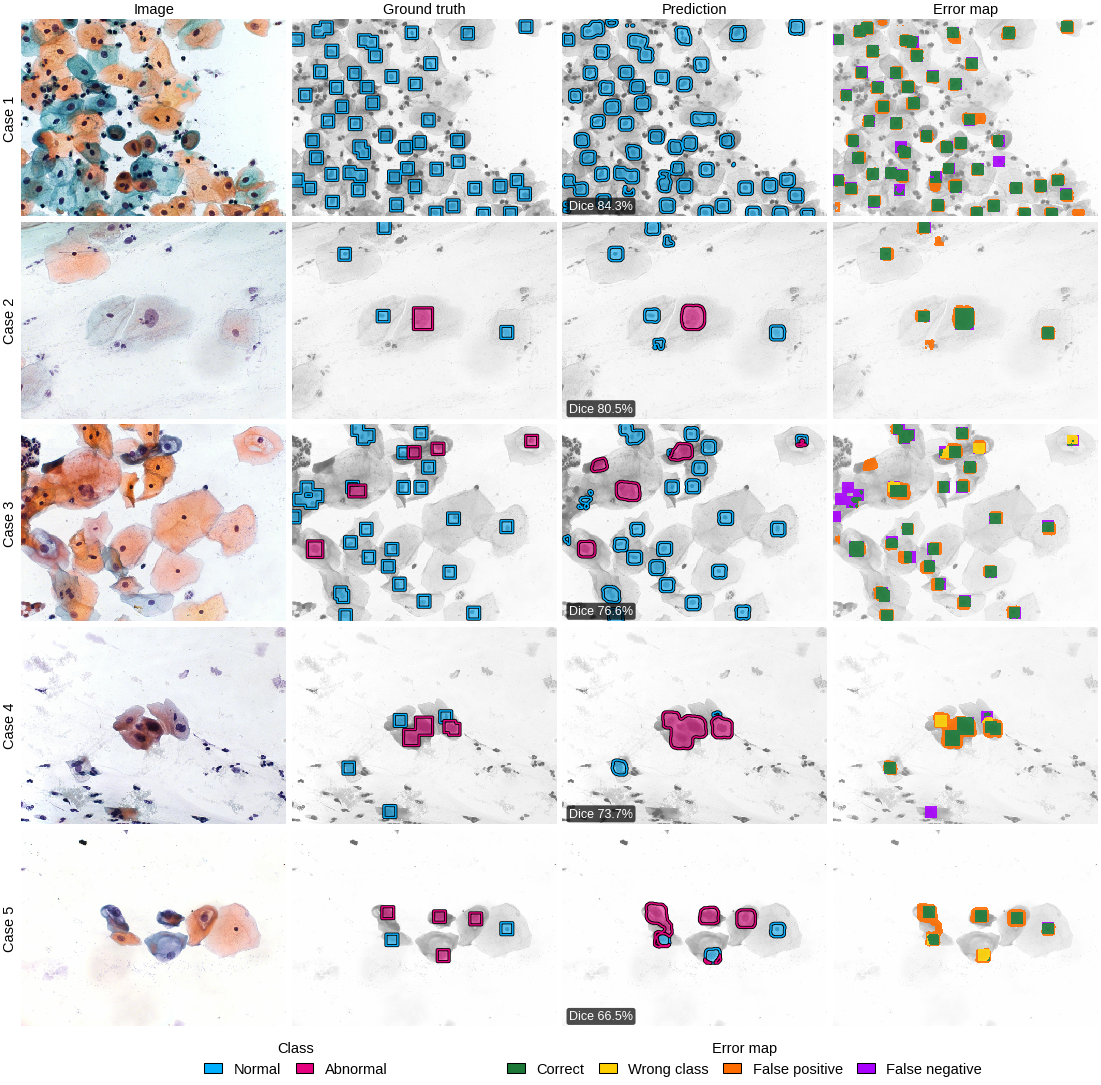

In [ ]:
# Fig. 6  Qualitative results: colour image, then overlays on a greyscale copy so colour only encodes labels
import matplotlib.patheffects as pe

VIS_CLASS = {}
for c in FG_CLASSES:
    VIS_CLASS[c] = "#E6007E" if "abnormal" in c.lower() else ("#00B0FF" if "normal" in c.lower() else "#FFD600")
ERR_COLORS = {"Correct": "#1B7837", "Wrong class": "#FFD000", "False positive": "#FF6D00", "False negative": "#AA00FF"}


def grey_bg(img, lo=0.35):
    g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255
    g = lo + (1 - lo) * g                      # lighten so coloured labels stand out
    return np.repeat(g[..., None], 3, 2)


def label_overlay(ax, img, mask, alpha=0.55):
    ax.imshow(grey_bg(img))
    rgba = np.zeros((*mask.shape, 4))
    for c in FG_CLASSES:
        rgba[mask == CLS_IDX[c]] = (*mpl.colors.to_rgb(VIS_CLASS[c]), alpha)
    ax.imshow(rgba)
    for c in FG_CLASSES:
        m = mask == CLS_IDX[c]
        if m.any():
            cs = ax.contour(m, levels=[0.5], colors=[VIS_CLASS[c]], linewidths=0.7)
            cs.set(path_effects=[pe.Stroke(linewidth=1.5, foreground="black"), pe.Normal()])
    image_axis(ax)


def error_overlay(ax, img, pred, gt, alpha=0.9):
    ax.imshow(grey_bg(img, lo=0.5))
    rgba = np.zeros((*gt.shape, 4))
    cases_ = {"Correct": (pred == gt) & (gt > 0), "Wrong class": (pred > 0) & (gt > 0) & (pred != gt),
              "False positive": (pred > 0) & (gt == 0), "False negative": (pred == 0) & (gt > 0)}
    for k, m in cases_.items():
        rgba[m] = (*mpl.colors.to_rgb(ERR_COLORS[k]), alpha)
    ax.imshow(rgba); image_axis(ax)


best_d = PER_IMAGE[PER_IMAGE.model == BEST].set_index("image")["Dice_FG"].dropna().sort_values()
qs = [0.95, 0.75, 0.5, 0.25, 0.05]   # 5 cases across the Dice range
cases = list(dict.fromkeys(best_d.index[np.clip((np.array(qs) * (len(best_d) - 1)).round().astype(int), 0, len(best_d) - 1)]))
rec_test = {r["stem"]: r for r in RECORDS["test"]}
single = len(CFG["MODELS"]) == 1
cols = ["Image", "Ground truth"] + (["Prediction"] if single else [SHORT[n] for n in CFG["MODELS"]]) + ["Error map"]

# figure height follows the image aspect ratio, so rows sit without gaps
n_r, n_c = len(cases), len(cols)
aspect = np.median([rec_test[s]["h"] / rec_test[s]["w"] for s in cases])
Wf, left, right, wsp, hsp = FIG_W["double"], 0.035, 0.995, 0.02, 0.03
axw = (right - left) * Wf / (n_c + (n_c - 1) * wsp); axh = axw * aspect
top_in, bot_in = 0.20, 0.42
Hf = top_in + bot_in + n_r * axh + (n_r - 1) * hsp * axh
fig, axs = plt.subplots(n_r, n_c, figsize=(Wf, Hf), squeeze=False)
fig.subplots_adjust(left=left, right=right, top=1 - top_in / Hf, bottom=bot_in / Hf, wspace=wsp, hspace=hsp)

for i, stem in enumerate(cases):
    r = rec_test[stem]; dsz = display_size(r["h"], r["w"])
    img = cv2.resize(read_rgb(r["img_path"]), dsz, interpolation=cv2.INTER_AREA)
    gt = cv2.resize(cv2.imread(r["mask_path"], cv2.IMREAD_UNCHANGED), dsz, interpolation=cv2.INTER_NEAREST)
    axs[i, 0].imshow(img); image_axis(axs[i, 0])
    label_overlay(axs[i, 1], img, gt)
    for j, n in enumerate(CFG["MODELS"]):
        ax = axs[i, 2 + j]; label_overlay(ax, img, PRED_SMALL[n][stem])
        dsc = PER_IMAGE[(PER_IMAGE.model == n) & (PER_IMAGE.image == stem)]["Dice_FG"].iloc[0]
        ax.text(0.025, 0.035, f"Dice {100 * dsc:.1f}%", transform=ax.transAxes, fontsize=6, color="white",
                bbox=dict(boxstyle="round,pad=0.2", fc="black", ec="none", alpha=0.7))
    error_overlay(axs[i, -1], img, PRED_SMALL[BEST][stem], gt)
    axs[i, 0].set_ylabel(f"Case {i + 1}", fontsize=7, labelpad=2)
for j, c in enumerate(cols):
    axs[0, j].set_title(c, fontsize=7, pad=3)

cls_h = [Patch(facecolor=VIS_CLASS[c], edgecolor="black", lw=0.5, label=c.capitalize()) for c in FG_CLASSES]
err_h = [Patch(facecolor=v, edgecolor="black", lw=0.5, label=k) for k, v in ERR_COLORS.items()]
leg1 = fig.legend(handles=cls_h, title="Class", loc="lower center", bbox_to_anchor=(0.28, 0.0), ncol=len(cls_h),
                  title_fontsize=7, handlelength=1.2, columnspacing=1.0)
fig.legend(handles=err_h, title="Error map", loc="lower center", bbox_to_anchor=(0.68, 0.0), ncol=len(err_h),
           title_fontsize=7, handlelength=1.2, columnspacing=1.0)
save_figure(fig, "Fig6_qualitative_comparison"); plt.show()

saved /content/gdrive/MyDrive/Edward/cervical/results_q1/figures/Fig7_probability_maps.{pdf,tiff,png}


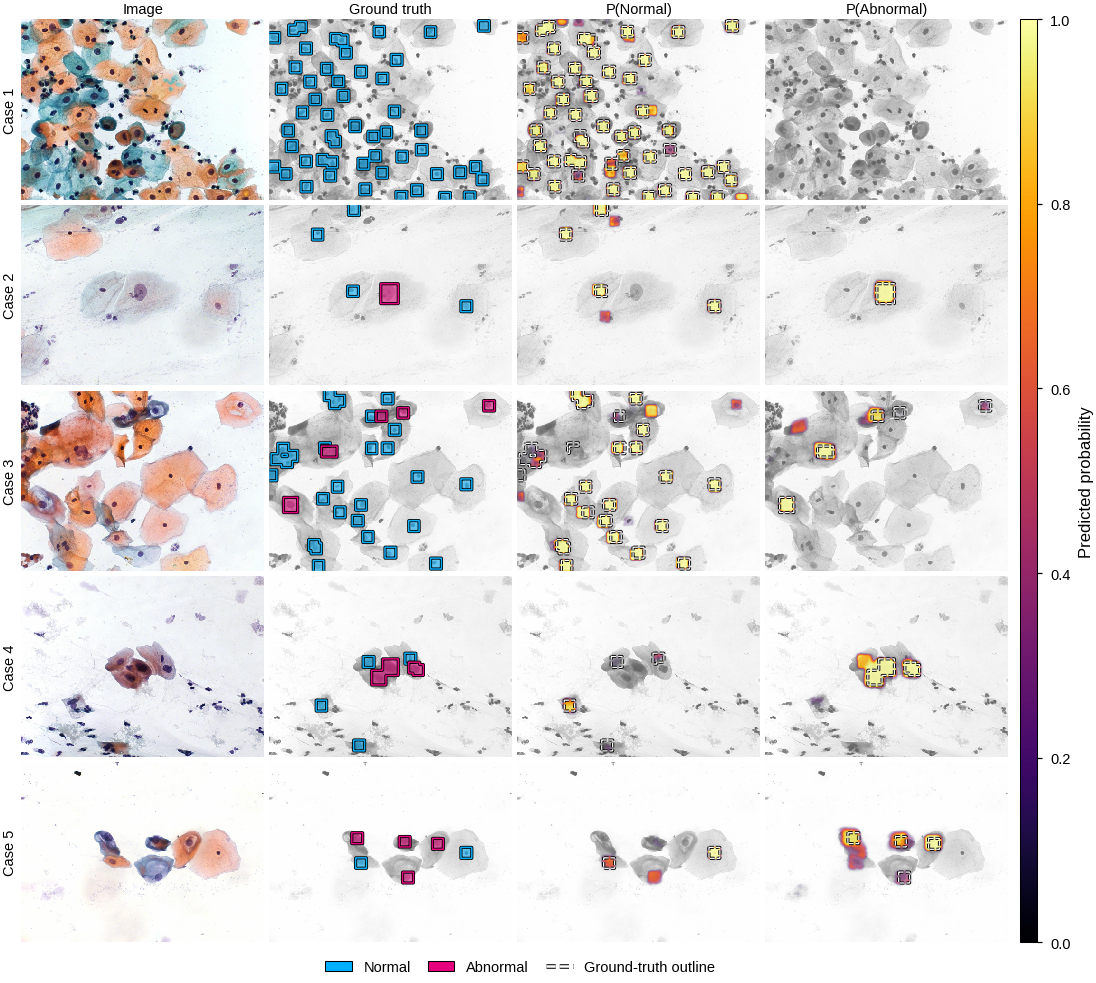

In [ ]:
# Fig. 7  Class probability maps of the best model (5 cases; heatmap blended into a greyscale image)
cmap = mpl.colormaps["inferno"]
pcases = cases[:5]


def prob_blend(img, p, gamma=1.5, amax=0.9):
    """Blend the heatmap into a greyscale copy by hand; low probability stays transparent."""
    a = np.clip(p * gamma, 0, amax)[..., None].astype(np.float32)
    return np.clip((1 - a) * grey_bg(img) + a * cmap(p)[..., :3], 0, 1)


def halo_contour(ax, m, color="white", lw=0.6, ls="--"):
    if m.any():
        cs = ax.contour(m, levels=[0.5], colors=[color], linewidths=lw, linestyles=ls)
        cs.set(path_effects=[pe.Stroke(linewidth=lw + 0.9, foreground="black"), pe.Normal()])


cols7 = ["Image", "Ground truth"] + [f"P({c.capitalize()})" for c in FG_CLASSES]
n_r, n_c = len(pcases), len(cols7)
aspect = np.median([rec_test[s]["h"] / rec_test[s]["w"] for s in pcases])
Wf, left, right, wsp, hsp = FIG_W["double"], 0.035, 0.915, 0.02, 0.03
axw = (right - left) * Wf / (n_c + (n_c - 1) * wsp); axh = axw * aspect
top_in, bot_in = 0.20, 0.30
Hf = top_in + bot_in + n_r * axh + (n_r - 1) * hsp * axh
fig, axs = plt.subplots(n_r, n_c, figsize=(Wf, Hf), squeeze=False)
fig.subplots_adjust(left=left, right=right, top=1 - top_in / Hf, bottom=bot_in / Hf, wspace=wsp, hspace=hsp)

for i, stem in enumerate(pcases):
    r = rec_test[stem]; dsz = display_size(r["h"], r["w"])
    img = cv2.resize(read_rgb(r["img_path"]), dsz, interpolation=cv2.INTER_AREA)
    gt = cv2.resize(cv2.imread(r["mask_path"], cv2.IMREAD_UNCHANGED), dsz, interpolation=cv2.INTER_NEAREST)
    axs[i, 0].imshow(img); image_axis(axs[i, 0]); axs[i, 0].set_ylabel(f"Case {i + 1}", fontsize=7, labelpad=2)
    label_overlay(axs[i, 1], img, gt)
    for j, c in enumerate(FG_CLASSES):
        ax = axs[i, 2 + j]
        pm = PROB_SMALL[BEST][stem][CLS_IDX[c]].astype(np.float32)
        pm = cv2.resize(pm, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_LINEAR)
        ax.imshow(prob_blend(img, pm))
        halo_contour(ax, gt == CLS_IDX[c])
        image_axis(ax)
for j, c in enumerate(cols7):
    axs[0, j].set_title(c, fontsize=7, pad=3)

cax = axs[-1, -1].inset_axes([1.05, 0, 0.07, n_r + (n_r - 1) * hsp])
cb = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(0, 1), cmap=cmap), cax=cax)
cb.set_label("Predicted probability"); cb.outline.set_linewidth(0.5)
leg = [Patch(facecolor=VIS_CLASS[c], edgecolor="black", lw=0.5, label=c.capitalize()) for c in FG_CLASSES]
leg += [Line2D([0], [0], color="white", lw=1.2, ls="--", path_effects=[pe.Stroke(linewidth=2.2, foreground="black"), pe.Normal()],
               label="Ground-truth outline")]
fig.legend(handles=leg, loc="lower center", bbox_to_anchor=(0.48, 0.0), ncol=len(leg), handlelength=1.8, columnspacing=1.2)
save_figure(fig, "Fig7_probability_maps"); plt.show()

bootstrap normal:   0%|          | 0/200 [00:00<?, ?it/s]

bootstrap abnormal:   0%|          | 0/200 [00:00<?, ?it/s]

saved /content/gdrive/MyDrive/Edward/cervical/results_q1/figures/Fig8_roc_pr_curves.{pdf,tiff,png}


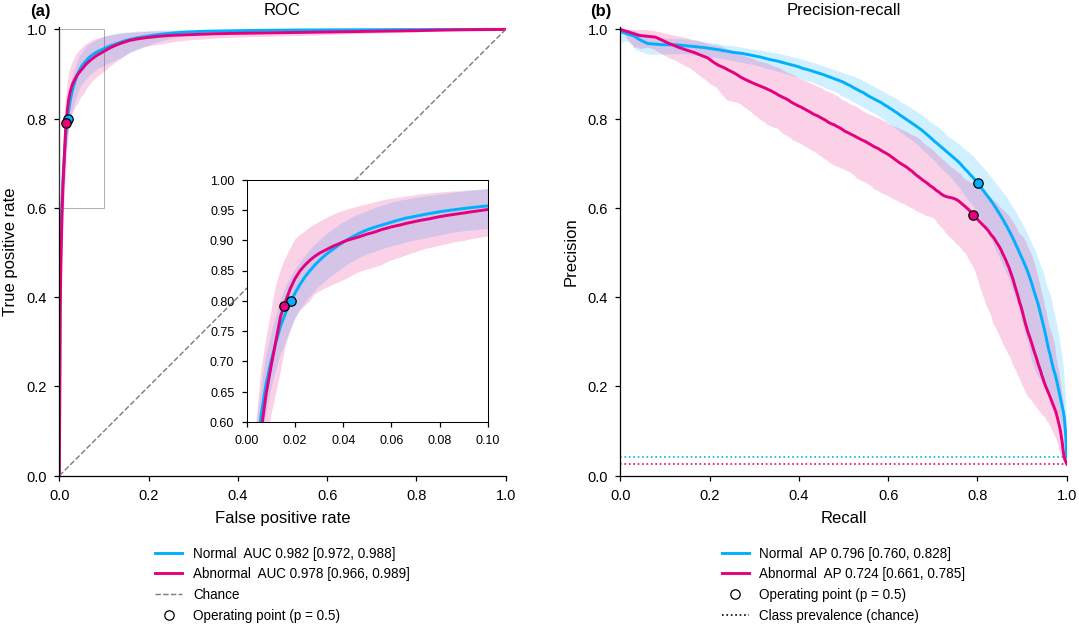

            model      cls  ROC_AUC  ROC_AUC_lo  ROC_AUC_hi     AP  AP_lo  AP_hi  prevalence  TPR_at_0_5  FPR_at_0_5  Precision_at_0_5
U-Net (ResNet-34)   normal   0.9820      0.9724      0.9884 0.7962 0.7600 0.8276      0.0418      0.8002      0.0184            0.6551
U-Net (ResNet-34) abnormal   0.9782      0.9658      0.9888 0.7238 0.6607 0.7847      0.0265      0.7907      0.0153            0.5849


In [ ]:
# Fig. 8  Pixel-level ROC and precision-recall curves of the best model, with 95% bootstrap bands over test images
N_BOOT_CURVE = 200 if not QUICK else 20
SUB_PX = 5000                                  # pixels per image inside each bootstrap draw
grid = np.linspace(0, 1, 501)
p_all, y_all = PIX[BEST]
n_img = len(RECORDS["test"]); blk = len(y_all) // n_img
blocks = [np.arange(i * blk, (i + 1) * blk) for i in range(n_img)] if blk * n_img == len(y_all) else None
rng = np.random.default_rng(CFG["SEED"])
VIS_CLASS = globals().get("VIS_CLASS", {c: CLASS_COLORS[c] for c in FG_CLASSES})


def curves(yb, sc):
    fpr, tpr, _ = roc_curve(yb, sc)
    prec, rec, _ = precision_recall_curve(yb, sc)
    o = np.argsort(rec)
    return np.interp(grid, fpr, tpr), np.interp(grid, rec[o], prec[o], left=1.0), auc(fpr, tpr), average_precision_score(yb, sc)


fig, (ax_r, ax_p) = plt.subplots(1, 2, figsize=(FIG_W["double"], 108 * MM), constrained_layout=True)
axin = ax_r.inset_axes([0.42, 0.12, 0.54, 0.54])
AUC_ROWS = []
for c in FG_CLASSES:
    ci, col = CLS_IDX[c], VIS_CLASS[c]
    yb, sc = (y_all == ci).astype(int), p_all[:, ci]
    if yb.sum() == 0:
        continue
    roc_m, pr_m, a, ap = curves(yb, sc)
    boots = []
    if blocks is not None:
        for _ in tqdm(range(N_BOOT_CURVE), desc=f"bootstrap {c}", leave=False):
            idx = np.concatenate([rng.choice(blocks[k], min(SUB_PX, blk), replace=False)
                                  for k in rng.integers(0, n_img, n_img)])
            if yb[idx].sum() == 0 or yb[idx].sum() == len(idx):
                continue
            boots.append(curves(yb[idx], sc[idx]))
    if boots:
        R = np.array([b[0] for b in boots]); P = np.array([b[1] for b in boots])
        A = np.array([b[2] for b in boots]); AP_ = np.array([b[3] for b in boots])
        a_ci, ap_ci = np.percentile(A, [2.5, 97.5]), np.percentile(AP_, [2.5, 97.5])
        for ax in (ax_r, axin):
            ax.fill_between(grid, *np.percentile(R, [2.5, 97.5], 0), color=col, alpha=0.18, lw=0)
        ax_p.fill_between(grid, *np.percentile(P, [2.5, 97.5], 0), color=col, alpha=0.18, lw=0)
        lab_r = f"{c.capitalize()}  AUC {a:.3f} [{a_ci[0]:.3f}, {a_ci[1]:.3f}]"
        lab_p = f"{c.capitalize()}  AP {ap:.3f} [{ap_ci[0]:.3f}, {ap_ci[1]:.3f}]"
    else:
        a_ci = ap_ci = (np.nan, np.nan)
        lab_r, lab_p = f"{c.capitalize()}  AUC {a:.3f}", f"{c.capitalize()}  AP {ap:.3f}"
    for ax in (ax_r, axin):
        ax.plot(grid, roc_m, color=col, lw=1.4, label=lab_r)
    ax_p.plot(grid, pr_m, color=col, lw=1.4, label=lab_p)

    # operating point at probability 0.5
    pr_ = sc >= 0.5
    tp, fp = (pr_ & (yb == 1)).sum(), (pr_ & (yb == 0)).sum()
    fn, tn = ((~pr_) & (yb == 1)).sum(), ((~pr_) & (yb == 0)).sum()
    op_tpr, op_fpr, op_prec = tp / max(tp + fn, 1), fp / max(fp + tn, 1), tp / max(tp + fp, 1)
    for ax in (ax_r, axin):
        ax.plot(op_fpr, op_tpr, "o", ms=4.5, mfc=col, mec="black", mew=0.6, zorder=5)
    ax_p.plot(op_tpr, op_prec, "o", ms=4.5, mfc=col, mec="black", mew=0.6, zorder=5)
    ax_p.axhline(yb.mean(), color=col, ls=":", lw=0.8)
    AUC_ROWS.append(dict(model=BEST, cls=c, ROC_AUC=a, ROC_AUC_lo=a_ci[0], ROC_AUC_hi=a_ci[1],
                         AP=ap, AP_lo=ap_ci[0], AP_hi=ap_ci[1], prevalence=yb.mean(),
                         TPR_at_0_5=op_tpr, FPR_at_0_5=op_fpr, Precision_at_0_5=op_prec))

ax_r.plot([0, 1], [0, 1], ls="--", color=OI["grey"], lw=0.7, label="Chance")
ax_r.set(xlabel="False positive rate", ylabel="True positive rate", xlim=(0, 1), ylim=(0, 1.005), title="ROC")
ax_p.set(xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1.005), title="Precision-recall")
axin.set(xlim=(0, 0.10), ylim=(0.6, 1.0)); axin.tick_params(labelsize=6)
for s_ in axin.spines.values():
    s_.set_visible(True); s_.set_linewidth(0.5)
_ind = ax_r.indicate_inset_zoom(axin, edgecolor="0.4", lw=0.5)
for _c in getattr(_ind, "connectors", None) or (_ind[1] if isinstance(_ind, tuple) else []):
    _c.set_visible(False)                      # keep the zoom rectangle, drop the connector lines
op = Line2D([0], [0], marker="o", ls="none", mfc="white", mec="black", mew=0.6, ms=4.5, label="Operating point (p = 0.5)")
h, l = ax_r.get_legend_handles_labels()
ax_r.legend(h + [op], l + [op.get_label()], loc="upper center", bbox_to_anchor=(0.5, -0.13), fontsize=6.5)
h, l = ax_p.get_legend_handles_labels()
prev_h = Line2D([0], [0], ls=":", color="black", lw=0.8, label="Class prevalence (chance)")
ax_p.legend(h + [op, prev_h], l + [op.get_label(), prev_h.get_label()], loc="upper center", bbox_to_anchor=(0.5, -0.13), fontsize=6.5)
for ax, L in zip((ax_r, ax_p), "ab"):
    ax.set_aspect("equal"); panel_label(ax, L)
save_figure(fig, "Fig8_roc_pr_curves"); plt.show()
AUC_TABLE = pd.DataFrame(AUC_ROWS).round(4)
AUC_TABLE.to_csv(os.path.join(DIRS["tables"], "table5_auc_ap.csv"), index=False)
print(AUC_TABLE.to_string(index=False))

saved /content/gdrive/MyDrive/Edward/cervical/results_q1/figures/Fig9_confusion_matrices.{pdf,tiff,png}


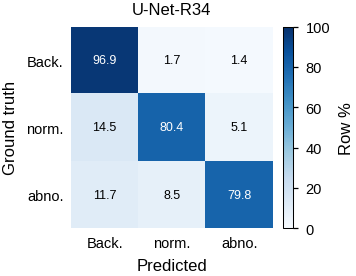

In [ ]:
# Fig. 9  Row-normalised pixel confusion matrices
fig, axs = plt.subplots(1, len(CFG["MODELS"]), figsize=(FIG_W["double"], 48 * MM), constrained_layout=True, squeeze=False)
for ax, name, L in zip(axs[0], CFG["MODELS"], "abcdefgh"):
    cm = CMS[name].astype(float); cmn = 100 * cm / cm.sum(1, keepdims=True).clip(min=1)
    im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=100)
    for a in range(NC):
        for b in range(NC):
            ax.text(b, a, f"{cmn[a, b]:.1f}", ha="center", va="center", fontsize=6,
                    color="white" if cmn[a, b] > 55 else "black")
    ax.set_xticks(range(NC), [c[:4] + "." if len(c) > 5 else c for c in CLASS_NAMES], rotation=0)
    ax.set_yticks(range(NC), [c[:4] + "." if len(c) > 5 else c for c in CLASS_NAMES] if L == "a" else [])
    ax.set_title(SHORT[name]); ax.set_xlabel("Predicted")
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0)
axs[0, 0].set_ylabel("Ground truth")
cb = fig.colorbar(im, ax=axs[0].tolist(), fraction=0.02, pad=0.01); cb.set_label("Row %"); cb.outline.set_linewidth(0.5)
save_figure(fig, "Fig9_confusion_matrices"); plt.show()

In [ ]:
# Fig. 10  Accuracy versus computational cost (only meaningful with several models)
if len(CFG["MODELS"]) > 1:
    fig, ax = plt.subplots(figsize=(FIG_W["single"], 65 * MM), constrained_layout=True)
    for k, name in enumerate(CFG["MODELS"]):
        d = PER_IMAGE[PER_IMAGE.model == name]["Dice_FG"].dropna()
        lo, hi = boot_ci(d)
        row = COST[COST.model == name].iloc[0]
        ax.errorbar(row.GFLOPs, 100 * d.mean(), yerr=[[100 * (d.mean() - lo)], [100 * (hi - d.mean())]],
                    fmt="none", ecolor=MODEL_COLORS[k], elinewidth=0.8, capsize=2)
        ax.scatter(row.GFLOPs, 100 * d.mean(), s=12 + 4 * row.params_M, color=MODEL_COLORS[k], edgecolor="k", lw=0.5, zorder=3)
        ax.annotate(SHORT[name], (row.GFLOPs, 100 * d.mean()), xytext=(5, 4 if k % 2 == 0 else -9), textcoords="offset points", fontsize=6)
    ax.set_xlabel(f"GFLOPs per forward pass ({IMG_H}×{IMG_W})"); ax.set_ylabel("Test Dice, foreground (%)")
    ax.text(0.98, 0.03, "Marker area scales with parameters\nBars: 95% bootstrap CI", transform=ax.transAxes, ha="right", va="bottom", fontsize=6, color=OI["grey"])
    ax.margins(x=0.25, y=0.2)
    save_figure(fig, "Fig10_accuracy_vs_cost"); plt.show()

In [ ]:
for sub in ["figures", "tables"]:
    print(f"\n{sub}/")
    for f in sorted(os.listdir(DIRS[sub])):
        print("  ", f)


figures/
   Fig1_dataset_overview.pdf
   Fig1_dataset_overview.png
   Fig1_dataset_overview.tiff
   Fig2_annotated_samples.pdf
   Fig2_annotated_samples.png
   Fig2_annotated_samples.tiff
   Fig3_preprocessing.pdf
   Fig3_preprocessing.png
   Fig3_preprocessing.tiff
   Fig4_learning_curves.pdf
   Fig4_learning_curves.png
   Fig4_learning_curves.tiff
   Fig5_dice_distributions.pdf
   Fig5_dice_distributions.png
   Fig5_dice_distributions.tiff
   Fig6_qualitative_comparison.pdf
   Fig6_qualitative_comparison.png
   Fig6_qualitative_comparison.tiff
   Fig7_probability_maps.pdf
   Fig7_probability_maps.png
   Fig7_probability_maps.tiff
   Fig8_roc_pr_curves.pdf
   Fig8_roc_pr_curves.png
   Fig8_roc_pr_curves.tiff
   Fig9_confusion_matrices.pdf
   Fig9_confusion_matrices.png
   Fig9_confusion_matrices.tiff
   Fig_segmentation_results.pdf
   Fig_segmentation_results.png
   Fig_segmentation_results.tiff

tables/
   per_image_test_metrics.csv
   table1_dataset.csv
   table1_dataset.tex
   tab

visual outputs:   0%|          | 0/104 [00:00<?, ?it/s]

saved /content/gdrive/MyDrive/Edward/cervical/results_q1/figures/Fig_segmentation_results.{pdf,tiff,png}


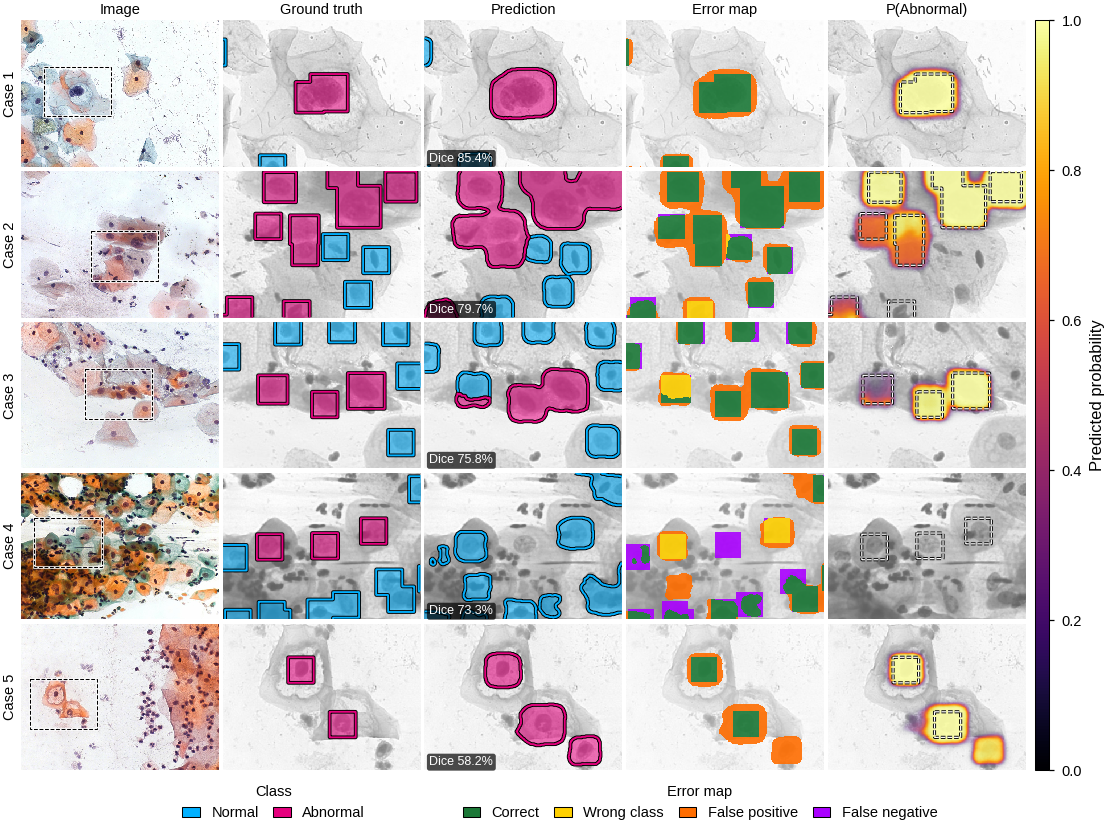

104 images written to /content/gdrive/MyDrive/Edward/cervical/results_q1/visual_outputs


In [ ]:
# ---------------------------------------------------------------------------
# Visual outputs (memory-safe: one image in RAM at a time)
#   1. figures/Fig_segmentation_results.{pdf,tiff,png}   5 cases, zoomed crops
#   2. visual_outputs/<image>_{overlay,mask,error,panel}.png   every test image
# ---------------------------------------------------------------------------
import gc
import matplotlib.patheffects as pe

VIS_DIR = os.path.join(CFG["OUT_DIR"], "visual_outputs")
os.makedirs(VIS_DIR, exist_ok=True)
NAME = CFG["MODELS"][0]
N_CASES = 5
SAVE_PANELS = True          # per-image 4-panel PNGs (set False to save time)
DISP_LONG = 768

VIS_CLASS = {c: ("#E6007E" if "abnormal" in c.lower() else "#00B0FF" if "normal" in c.lower() else "#FFD600")
             for c in FG_CLASSES}
ERR_COLORS = {"Correct": "#1B7837", "Wrong class": "#FFD000", "False positive": "#FF6D00", "False negative": "#AA00FF"}
CLS_RGB = {CLS_IDX[c]: np.array(mpl.colors.to_rgb(v), np.float32) for c, v in VIS_CLASS.items()}
ERR_RGB = {k: np.array(mpl.colors.to_rgb(v), np.float32) for k, v in ERR_COLORS.items()}


def err_cases(pred, gt):
    return {"Correct": (pred == gt) & (gt > 0), "Wrong class": (pred > 0) & (gt > 0) & (pred != gt),
            "False positive": (pred > 0) & (gt == 0), "False negative": (pred == 0) & (gt > 0)}


def grey_bg(img, lo=0.35):
    g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255
    return np.repeat((lo + (1 - lo) * g)[..., None], 3, 2)


def paint(base01, label_map, colors, alpha):
    out = base01.copy()
    for k, m in label_map.items():
        out[m] = (1 - alpha) * out[m] + alpha * colors[k]
    return out


def to_u8(a):
    return (np.clip(a, 0, 1) * 255).astype(np.uint8)


def contour_u8(img_u8, mask, rgb, thick):
    cnts, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(img_u8, cnts, -1, (0, 0, 0), thick + 2, cv2.LINE_AA)
    cv2.drawContours(img_u8, cnts, -1, tuple(int(255 * v) for v in rgb), thick, cv2.LINE_AA)
    return img_u8


def label_ax(ax, img, mask, alpha=0.55, lw=0.7):
    ax.imshow(to_u8(paint(grey_bg(img), {c: mask == c for c in CLS_RGB}, CLS_RGB, alpha)))
    for c, rgb in CLS_RGB.items():
        m = mask == c
        if m.any():
            cs = ax.contour(m, levels=[0.5], colors=[tuple(rgb)], linewidths=lw)
            cs.set(path_effects=[pe.Stroke(linewidth=lw + 0.9, foreground="black"), pe.Normal()])
    image_axis(ax)


def error_ax(ax, img, pred, gt):
    ax.imshow(to_u8(paint(grey_bg(img, 0.5), err_cases(pred, gt), ERR_RGB, 0.9))); image_axis(ax)


def zoom_window(gt, pred, frac=0.34):
    H, W = gt.shape
    h, w = int(H * frac), int(W * frac)
    fg = (gt > 0) if gt.any() else (pred > 0)
    if not fg.any():
        return (H - h) // 2, (W - w) // 2, h, w
    dens = cv2.boxFilter(fg.astype(np.float32), -1, (w, h), normalize=False, borderType=cv2.BORDER_CONSTANT)
    ys, xs = np.nonzero(dens >= dens.max() * 0.98)          # all near-best windows
    cy, cx = int(np.median(ys)), int(np.median(xs))       # middle of them, so cells sit centred
    return int(np.clip(cy - h // 2, 0, H - h)), int(np.clip(cx - w // 2, 0, W - w)), h, w


def predict_small(model, i):
    """Prediction for test image i, returned at display size only."""
    r = RECORDS["test"][i]
    x, _, _ = vis_ds[i]
    gt = cv2.imread(r["mask_path"], cv2.IMREAD_UNCHANGED)
    prob = predict_probs(model, x[None].to(DEVICE), gt.shape)
    pred = prob.argmax(0).astype(np.uint8)
    dice = binary_metrics(pred > 0, gt > 0)["Dice"]
    img = read_rgb(r["img_path"])
    return r, img, gt, pred, prob, dice


model, _ = load_best(NAME)
vis_ds = PapSegDataset(RECORDS["test"], eval_tf)
rows = []
for i in tqdm(range(len(RECORDS["test"])), desc="visual outputs"):
    r, img, gt, pred, prob, dice = predict_small(model, i)
    del prob
    rows.append(dict(idx=i, image=r["stem"], dice_fg=dice,
                     n_abn_px=int((gt == CLS_IDX[[c for c in FG_CLASSES if "abnormal" in c.lower()][0]]).sum())
                     if any("abnormal" in c.lower() for c in FG_CLASSES) else 0))
    t = max(2, round(max(gt.shape) / 600))

    ov = contour_u8(to_u8(paint(img.astype(np.float32) / 255, {c: pred == c for c in CLS_RGB}, CLS_RGB, 0.45)),
                    gt > 0, (1, 1, 1), t)
    cv2.imwrite(os.path.join(VIS_DIR, f"{r['stem']}_overlay.png"), cv2.cvtColor(ov, cv2.COLOR_RGB2BGR))
    lm = np.zeros((*pred.shape, 3), np.uint8)
    for c, rgb in CLS_RGB.items():
        lm[pred == c] = (255 * rgb).astype(np.uint8)
    cv2.imwrite(os.path.join(VIS_DIR, f"{r['stem']}_mask.png"), cv2.cvtColor(lm, cv2.COLOR_RGB2BGR))
    er = to_u8(paint(grey_bg(img, 0.5), err_cases(pred, gt), ERR_RGB, 0.9))
    cv2.imwrite(os.path.join(VIS_DIR, f"{r['stem']}_error.png"), cv2.cvtColor(er, cv2.COLOR_RGB2BGR))
    del ov, lm, er

    if SAVE_PANELS:
        dsz = display_size(*gt.shape, long=DISP_LONG)
        im_s = cv2.resize(img, dsz, interpolation=cv2.INTER_AREA)
        gt_s = cv2.resize(gt, dsz, interpolation=cv2.INTER_NEAREST)
        pr_s = cv2.resize(pred, dsz, interpolation=cv2.INTER_NEAREST)
        fig, axs = plt.subplots(1, 4, figsize=(FIG_W["double"], 42 * MM), gridspec_kw=dict(wspace=0.03))
        axs[0].imshow(im_s); image_axis(axs[0]); axs[0].set_title("Image")
        label_ax(axs[1], im_s, gt_s); axs[1].set_title("Ground truth")
        label_ax(axs[2], im_s, pr_s)
        axs[2].set_title("Prediction" if np.isnan(dice) else f"Prediction (Dice {100 * dice:.1f}%)")
        error_ax(axs[3], im_s, pr_s, gt_s); axs[3].set_title("Error map")
        fig.savefig(os.path.join(VIS_DIR, f"{r['stem']}_panel.png"), dpi=300, bbox_inches="tight")
        plt.close(fig)
    del img, gt, pred
    if i % 10 == 0:
        gc.collect()

VIS_DICE = pd.DataFrame(rows).sort_values("dice_fg", ascending=False)
VIS_DICE.drop(columns=["idx", "n_abn_px"]).to_csv(os.path.join(VIS_DIR, "per_image_dice.csv"), index=False)

# --- paper figure: 5 cases across the Dice range, zoomed crops ------------
valid = VIS_DICE.dropna()
if (valid.n_abn_px > 0).sum() >= N_CASES:          # show cases that contain abnormal cells
    valid = valid[valid.n_abn_px > 0]
valid = valid.reset_index(drop=True)
qs = np.linspace(0.02, 0.98, N_CASES)
pick = list(dict.fromkeys(valid.idx.iloc[np.round(qs * (len(valid) - 1)).astype(int)]))
abn = [c for c in FG_CLASSES if "abnormal" in c.lower()]
prob_cls = abn[0] if abn else FG_CLASSES[-1]
cols = ["Image", "Ground truth", "Prediction", "Error map", f"P({prob_cls.capitalize()})"]

CASES = []
for i in pick:                                   # re-predict only the 5 chosen images
    r, img, gt, pred, prob, dice = predict_small(model, i)
    dsz = display_size(*gt.shape, long=1024)
    CASES.append(dict(img=cv2.resize(img, dsz, interpolation=cv2.INTER_AREA),
                      gt=cv2.resize(gt, dsz, interpolation=cv2.INTER_NEAREST),
                      pred=cv2.resize(pred, dsz, interpolation=cv2.INTER_NEAREST),
                      p=cv2.resize(prob[CLS_IDX[prob_cls]], dsz, interpolation=cv2.INTER_AREA), dice=dice))
    del img, gt, pred, prob
del model; gc.collect(); torch.cuda.empty_cache()

n_r, n_c = len(CASES), len(cols)
aspect = CASES[0]["img"].shape[0] / CASES[0]["img"].shape[1]
Wf, left, right, wsp, hsp = FIG_W["double"], 0.035, 0.93, 0.02, 0.03
axw = (right - left) * Wf / (n_c + (n_c - 1) * wsp); axh = axw * aspect
top_in, bot_in = 0.20, 0.42
Hf = top_in + bot_in + n_r * axh + (n_r - 1) * hsp * axh
fig, axs = plt.subplots(n_r, n_c, figsize=(Wf, Hf), squeeze=False)
fig.subplots_adjust(left=left, right=right, top=1 - top_in / Hf, bottom=bot_in / Hf, wspace=wsp, hspace=hsp)

for i, v in enumerate(CASES):
    abn_m = v["gt"] == CLS_IDX[prob_cls]
    y0, x0, h, w = zoom_window(np.where(abn_m, v["gt"], 0) if abn_m.any() else v["gt"], v["pred"])   # centre on abnormal cells
    img_c, gt_c, pr_c, p_c = (v["img"][y0:y0 + h, x0:x0 + w], v["gt"][y0:y0 + h, x0:x0 + w],
                              v["pred"][y0:y0 + h, x0:x0 + w], v["p"][y0:y0 + h, x0:x0 + w])
    ax = axs[i, 0]; ax.imshow(v["img"]); image_axis(ax)
    ax.add_patch(mpl.patches.Rectangle((x0, y0), w, h, fill=False, ec="white", lw=1.2))
    ax.add_patch(mpl.patches.Rectangle((x0, y0), w, h, fill=False, ec="black", lw=0.5, ls="--"))
    ax.set_ylabel(f"Case {i + 1}", fontsize=7, labelpad=2)
    label_ax(axs[i, 1], img_c, gt_c, lw=0.9)
    label_ax(axs[i, 2], img_c, pr_c, lw=0.9)
    axs[i, 2].text(0.025, 0.035, f"Dice {100 * v['dice']:.1f}%", transform=axs[i, 2].transAxes, fontsize=6,
                   color="white", bbox=dict(boxstyle="round,pad=0.2", fc="black", ec="none", alpha=0.7))
    error_ax(axs[i, 3], img_c, pr_c, gt_c)
    ax = axs[i, 4]
    a_ = np.clip(p_c * 1.5, 0, 0.9)[..., None].astype(np.float32)          # manual blend (array alpha is unreliable)
    ax.imshow(np.clip((1 - a_) * grey_bg(img_c) + a_ * mpl.colormaps["inferno"](p_c)[..., :3], 0, 1))
    m_ = gt_c == CLS_IDX[prob_cls]
    if m_.any():
        cs = ax.contour(m_, levels=[0.5], colors="white", linewidths=0.6, linestyles="--")
        cs.set(path_effects=[pe.Stroke(linewidth=1.5, foreground="black"), pe.Normal()])
    image_axis(ax)
for j, c in enumerate(cols):
    axs[0, j].set_title(c, fontsize=7, pad=3)

cax = axs[-1, -1].inset_axes([1.05, 0, 0.07, n_r + (n_r - 1) * hsp])
cb = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(0, 1), cmap="inferno"), cax=cax); cb.set_label("Predicted probability"); cb.outline.set_linewidth(0.5)
cls_h = [Patch(facecolor=VIS_CLASS[c], edgecolor="black", lw=0.5, label=c.capitalize()) for c in FG_CLASSES]
err_h = [Patch(facecolor=v, edgecolor="black", lw=0.5, label=k) for k, v in ERR_COLORS.items()]
fig.legend(handles=cls_h, title="Class", loc="lower center", bbox_to_anchor=(0.26, 0.0), ncol=len(cls_h),
           title_fontsize=7, handlelength=1.2, columnspacing=1.0)
fig.legend(handles=err_h, title="Error map", loc="lower center", bbox_to_anchor=(0.64, 0.0), ncol=len(err_h),
           title_fontsize=7, handlelength=1.2, columnspacing=1.0)
save_figure(fig, "Fig_segmentation_results"); plt.show()
del CASES; plt.close("all"); gc.collect()
print(f"{len(rows)} images written to {VIS_DIR}")

966 full-field images: {'Superficial-Intermediate': 126, 'Parabasal': 108, 'Metaplastic': 271, 'Koilocytotic': 238, 'Dyskeratotic': 223}
MTA-TransUNet (ours): 4049 cells done
SegFormer: 4049 cells done
U-Net++: 4049 cells done
               Model  Images  Cells Cell AUC     AUC 95% CI Accuracy (%) Balanced acc. (%) Sensitivity (%) Specificity (%) Precision (%) F1 (%) Detection rate (%) Image AUC
MTA-TransUNet (ours)     966   4049    0.719 [0.684, 0.753]        66.46             66.51           66.79           66.24         57.34  61.70              47.89     0.783
           SegFormer     966   4049    0.719 [0.681, 0.753]        68.12             66.94           60.81           73.08         60.55  60.68              54.56     0.782
             U-Net++     966   4049    0.766 [0.729, 0.798]        72.86             71.87           66.67           77.06         66.38  66.52              51.05     0.825 

               Cell type    Group  Cells MTA-TransUNet (ours) (%) SegFormer (%)

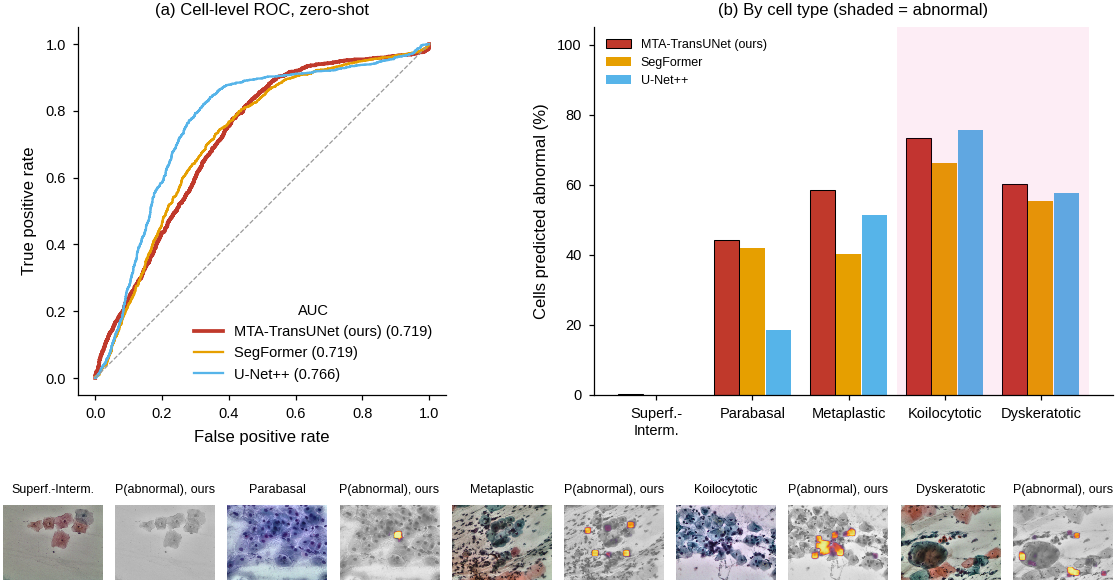

adaptation split: 194 training images, 772 test images
[MTA-TransUNet (ours)] epoch 1/15 loss 1.5008
[MTA-TransUNet (ours)] epoch 2/15 loss 1.1619
[MTA-TransUNet (ours)] epoch 3/15 loss 1.0772
[MTA-TransUNet (ours)] epoch 4/15 loss 0.9533
[MTA-TransUNet (ours)] epoch 5/15 loss 0.8899
[MTA-TransUNet (ours)] epoch 6/15 loss 0.8581
[MTA-TransUNet (ours)] epoch 7/15 loss 0.8221
[MTA-TransUNet (ours)] epoch 8/15 loss 0.7387
[MTA-TransUNet (ours)] epoch 9/15 loss 0.6887
[MTA-TransUNet (ours)] epoch 10/15 loss 0.6146
[MTA-TransUNet (ours)] epoch 11/15 loss 0.6195
[MTA-TransUNet (ours)] epoch 12/15 loss 0.5947
[MTA-TransUNet (ours)] epoch 13/15 loss 0.5664
[MTA-TransUNet (ours)] epoch 14/15 loss 0.5427
[MTA-TransUNet (ours)] epoch 15/15 loss 0.5459
[SegFormer] epoch 1/15 loss 1.3069
[SegFormer] epoch 2/15 loss 1.0241
[SegFormer] epoch 3/15 loss 0.9350
[SegFormer] epoch 4/15 loss 0.8161
[SegFormer] epoch 5/15 loss 0.6960
[SegFormer] epoch 6/15 loss 0.6852
[SegFormer] epoch 7/15 loss 0.6591
[Seg

KeyboardInterrupt: 

In [ ]:
# %%
# SIPaKMeD full-field external study (standalone, low RAM): zero-shot on all images for 3 models + paired tests
import os, re, glob, shutil, subprocess, gc, math, numpy as np, pandas as pd, cv2, torch, torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
try:
    import segmentation_models_pytorch as smp
except ImportError:
    subprocess.run(["pip", "install", "-q", "segmentation-models-pytorch"]); import segmentation_models_pytorch as smp

ROOT = os.environ.get("CERVIX_ROOT", "/content/gdrive/MyDrive/cervical")
if ROOT.startswith("/content/gdrive") and not os.path.exists("/content/gdrive/MyDrive"):
    from google.colab import drive; drive.mount("/content/gdrive")
RES = f"{ROOT}/results_q1_proposed"; CK, OUT, FIG = f"{RES}/checkpoints", f"{RES}/tables", f"{RES}/figures"
ARCH = os.environ.get("CERVIX_SPK_DRIVE", f"{os.path.dirname(ROOT)}/external/SIPaKMeD_full")
LOCAL = "/content/spk" if os.path.exists("/content") else "/tmp/spk"
PER_CLASS = int(os.environ.get("SPK_PER_CLASS", 1000))               # 1000 = all images
IMG_H, IMG_W, SEED, N_BOOT = 384, 512, 42, 1000
CLASSES = ["Superficial-Intermediate", "Parabasal", "Metaplastic", "Koilocytotic", "Dyskeratotic"]
ABN_T = {"Koilocytotic", "Dyskeratotic"}
MODELS = {"MTA-TransUNet (ours)": "w_o_scSE_attention", "SegFormer": "SegFormer__MiT_B2", "U-Net++": "U_Net____R34"}
COL = {"MTA-TransUNet (ours)": "#C0392B", "SegFormer": "#E69F00", "U-Net++": "#56B4E9"}
OURS = "MTA-TransUNet (ours)"
DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu"); AMP = DEV.type == "cuda"
for d in (OUT, FIG):
    os.makedirs(d, exist_ok=True)

if not os.path.isdir(LOCAL):                                          # unpack full fields + contours (crops skipped)
    for a in sorted(glob.glob(f"{ARCH}/*.7z")):
        if shutil.which("7z"):
            subprocess.run(["7z", "x", a, f"-o{LOCAL}", "-xr!CROPPED", "-y", "-bso0", "-bsp0"], check=True)
        else:
            import py7zr
            with py7zr.SevenZipFile(a) as z:
                names = [n for n in z.getnames() if "cropped" not in n.lower()]
            with py7zr.SevenZipFile(a) as z:
                z.extract(path=LOCAL, targets=names)


def read_dat(p, w, h):
    v = np.array(re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", open(p, errors="ignore").read()), float)
    q = v[: len(v) // 2 * 2].reshape(-1, 2)
    return q[:, ::-1] if len(q) and (q[:, 0].max() > w + 2 or q[:, 1].max() > h + 2) else q


ITEMS = []
for bmp in sorted(glob.glob(f"{LOCAL}/**/*.bmp", recursive=True)):
    cls = next((c for c in CLASSES if c.split("-")[0].lower() in bmp.lower()), None)
    dats = sorted(glob.glob(bmp[:-4] + "_cyt*.dat")) or sorted(glob.glob(bmp[:-4] + "_nuc*.dat"))
    if "cropped" not in bmp.lower() and cls and dats:
        ITEMS.append(dict(path=bmp, cls=cls, label=int(cls in ABN_T), dats=dats, id=f"{cls[:4]}_{os.path.basename(bmp)[:-4]}"))
rs = np.random.default_rng(SEED); _sel = []
for c in CLASSES:
    g = [i for i in ITEMS if i["cls"] == c]
    _sel += [g[j] for j in sorted(rs.choice(len(g), min(PER_CLASS, len(g)), replace=False))]
ITEMS = _sel
print(f"{len(ITEMS)} full-field images:", pd.Series([i['cls'] for i in ITEMS]).value_counts().reindex(CLASSES).to_dict())


def build(name):
    if name == OURS:
        class Net(torch.nn.Module):
            def __init__(self):
                super().__init__()
                self.net = smp.Unet("mit_b2", encoder_weights=None, classes=3, aux_params=dict(classes=1, dropout=0.2))
                self.segmentation_head = self.net.segmentation_head

            def forward(self, x):
                out = self.net(x)
                return out if self.training else out[0]
        return Net()
    if name == "SegFormer":
        return smp.Segformer("mit_b2", encoder_weights=None, classes=3)
    return smp.UnetPlusPlus("resnet34", encoder_weights=None, classes=3)


def load(name, path=None):
    m = build(name); m.load_state_dict(torch.load(path or f"{CK}/{MODELS[name]}.pt", map_location="cpu", weights_only=False)["model"])
    return m.to(DEV).eval()


MEAN, STD = np.array([0.485, 0.456, 0.406]) * 255, np.array([0.229, 0.224, 0.225]) * 255


def prep(it):
    """Half-size decode, CLAHE, network size; per-cell masks at network size; 3-class label map."""
    im = cv2.imread(it["path"], cv2.IMREAD_REDUCED_COLOR_2); h, w = im.shape[:2]; H, W = 2 * h, 2 * w
    lab = cv2.cvtColor(cv2.cvtColor(im, cv2.COLOR_BGR2RGB), cv2.COLOR_RGB2LAB)
    lab[..., 0] = cv2.createCLAHE(2.0, (8, 8)).apply(lab[..., 0])
    im = cv2.resize(cv2.cvtColor(lab, cv2.COLOR_LAB2RGB), (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)
    masks, lbl = [], np.zeros((IMG_H, IMG_W), np.uint8)
    for d in it["dats"]:
        q = read_dat(d, W, H)
        if len(q) >= 3:
            mk = np.zeros((IMG_H, IMG_W), np.uint8)
            cv2.fillPoly(mk, [np.round(q * [IMG_W / W, IMG_H / H]).astype(np.int32)], 1)
            if mk.any():
                masks.append(mk.astype(bool)); lbl[mk.astype(bool)] = 2 if it["label"] else 1
    return im, masks, lbl


def to_t(im):
    return torch.from_numpy(((im - MEAN) / STD).transpose(2, 0, 1)).float()


@torch.no_grad()
def evaluate(model, items, name, keep_example=False):
    cells, imgs, ex = [], [], {}
    for it in items:
        im, masks, _ = prep(it); x = to_t(im)[None].to(DEV)
        with torch.autocast(DEV.type, dtype=torch.float16, enabled=AMP):
            p = (model(x).float().softmax(1) + model(x.flip(-1)).float().softmax(1).flip(-1)
                 + model(x.flip(-2)).float().softmax(1).flip(-2))[0].cpu().numpy() / 3
        imgs.append(dict(model=name, image=it["id"], cls=it["cls"], label=it["label"], score=float(np.percentile(p[2], 99.5))))
        for mk in masks:
            mp = p[:, mk].mean(1)
            cells.append(dict(model=name, image=it["id"], cls=it["cls"], y=it["label"], p_abn=float(mp[2] / (mp[1] + mp[2] + 1e-8)),
                              pred=int(mp[2] > mp[1]), detected=bool(1 - mp[0] >= 0.5)))
        if keep_example and it["cls"] not in ex and len(masks) >= 3:
            ex[it["cls"]] = (im, p[2].astype(np.float16))
        del x, p
    return pd.DataFrame(cells), pd.DataFrame(imgs), ex


def boot_idx(C, n=N_BOOT, seed=SEED):
    ims = sorted(C.image.unique()); r = np.random.default_rng(seed)
    return ims, [r.integers(0, len(ims), len(ims)) for _ in range(n)]


def boot_auc(C, ims, draws):
    grp = C.groupby("image").indices; y, s = C.y.values, C.p_abn.values; out = []
    for b in draws:
        ix = np.concatenate([grp[ims[j]] for j in b if ims[j] in grp])
        out.append(roc_auc_score(y[ix], s[ix]) if 0 < y[ix].sum() < len(ix) else np.nan)
    return np.array(out)


def summary(C, I, auc_b):
    y, s, pr = C.y.values, C.p_abn.values, C.pred.values
    tp, tn = ((pr == 1) & (y == 1)).sum(), ((pr == 0) & (y == 0)).sum()
    fp, fn = ((pr == 1) & (y == 0)).sum(), ((pr == 0) & (y == 1)).sum()
    se, sp, pc = tp / max(tp + fn, 1), tn / max(tn + fp, 1), tp / max(tp + fp, 1)
    return {"Images": I.image.nunique(), "Cells": len(C), "Cell AUC": f"{roc_auc_score(y, s):.3f}",
            "AUC 95% CI": f"[{np.nanpercentile(auc_b, 2.5):.3f}, {np.nanpercentile(auc_b, 97.5):.3f}]",
            "Accuracy (%)": f"{100 * (tp + tn) / len(y):.2f}", "Balanced acc. (%)": f"{50 * (se + sp):.2f}",
            "Sensitivity (%)": f"{100 * se:.2f}", "Specificity (%)": f"{100 * sp:.2f}", "Precision (%)": f"{100 * pc:.2f}",
            "F1 (%)": f"{200 * pc * se / max(pc + se, 1e-8):.2f}", "Detection rate (%)": f"{100 * C.detected.mean():.2f}",
            "Image AUC": f"{roc_auc_score(I.label, I.score):.3f}"}


def holm(p):
    p = np.asarray(p); o = np.argsort(p); adj = np.empty(len(p)); run = 0
    for k, i in enumerate(o):
        run = max(run, min(1.0, (len(p) - k) * p[i])); adj[i] = run
    return adj


def paired_table(C_all, ims, draws, tag):
    AB = {n: boot_auc(C_all[C_all.model == n], ims, draws) for n in MODELS}
    rows = []
    for b in [n for n in MODELS if n != OURS]:
        d = AB[OURS] - AB[b]; d = d[~np.isnan(d)]
        obs = roc_auc_score(C_all[C_all.model == OURS].y, C_all[C_all.model == OURS].p_abn) - \
              roc_auc_score(C_all[C_all.model == b].y, C_all[C_all.model == b].p_abn)
        rows.append({"Comparison": f"Ours vs {b}", "Δ cell AUC": f"{obs:+.3f}",
                     "95% CI": f"[{np.percentile(d, 2.5):+.3f}, {np.percentile(d, 97.5):+.3f}]",
                     "p": max(min(1.0, 2 * min((d <= 0).mean(), (d >= 0).mean())), 1 / len(d))})
    T = pd.DataFrame(rows); T["p (Holm)"] = [f"{v:.1e}" for v in holm(T.p)]
    T["Sig."] = ["***" if v < 1e-3 else "**" if v < 1e-2 else "*" if v < 0.05 else "n.s." for v in holm(T.p)]
    T = T.drop(columns="p"); T.to_csv(f"{OUT}/{tag}.csv", index=False); return T, AB


ZS_C, ZS_I, EX = [], [], {}
for n in MODELS:                                                        # one model in memory at a time
    m = load(n); c_, i_, e_ = evaluate(m, ITEMS, n, keep_example=(n == OURS))
    ZS_C.append(c_); ZS_I.append(i_); EX.update(e_); del m; gc.collect(); torch.cuda.empty_cache()
    print(f"{n}: {len(c_)} cells done")
ZS_C, ZS_I = pd.concat(ZS_C, ignore_index=True), pd.concat(ZS_I, ignore_index=True)
ZS_C.to_csv(f"{OUT}/sipakmed_zeroshot_cells.csv", index=False)
ims, draws = boot_idx(ZS_C[ZS_C.model == OURS])
T17, ABZ = paired_table(ZS_C, ims, draws, "table17_sipakmed_zeroshot_tests")
T15 = pd.DataFrame([{"Model": n, **summary(ZS_C[ZS_C.model == n], ZS_I[ZS_I.model == n], ABZ[n])} for n in MODELS])
T16 = pd.DataFrame([{"Cell type": c, "Group": "Abnormal" if c in ABN_T else "Normal", "Cells": int(((ZS_C.model == OURS) & (ZS_C.cls == c)).sum()),
                     **{f"{n} (%)": f"{100 * ZS_C[(ZS_C.model == n) & (ZS_C.cls == c)].pred.mean():.1f}" for n in MODELS}} for c in CLASSES])
T15.to_csv(f"{OUT}/table15_sipakmed_zeroshot.csv", index=False); T16.to_csv(f"{OUT}/table16_sipakmed_zeroshot_per_type.csv", index=False)
for t in (T15, T16, T17):
    print(t.to_string(index=False), "\n")

MM = 1 / 25.4
plt.rcParams.update({"font.size": 7, "axes.spines.top": False, "axes.spines.right": False, "pdf.fonttype": 42, "legend.frameon": False})
TYPE_LAB = ["Superf.-\nInterm.", "Parabasal", "Metaplastic", "Koilocytotic", "Dyskeratotic"]


def save(fig, name):
    fig.savefig(f"{FIG}/{name}.pdf", bbox_inches="tight"); fig.savefig(f"{FIG}/{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"{FIG}/{name}.tiff", dpi=600, bbox_inches="tight", pil_kwargs={"compression": "tiff_lzw"})


fig = plt.figure(figsize=(190 * MM, 108 * MM), constrained_layout=True); gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.5])
ax = fig.add_subplot(gs[0, 0])
for n in MODELS:
    d = ZS_C[ZS_C.model == n]; f_, t_, _ = roc_curve(d.y, d.p_abn)
    ax.plot(f_, t_, color=COL[n], lw=1.8 if n == OURS else 1.1, label=f"{n} ({roc_auc_score(d.y, d.p_abn):.3f})")
ax.plot([0, 1], [0, 1], "--", color="0.6", lw=0.6); ax.set_aspect("equal")
ax.set(xlabel="False positive rate", ylabel="True positive rate", title="(a) Cell-level ROC, zero-shot"); ax.legend(title="AUC", loc="lower right")
ax = fig.add_subplot(gs[0, 1]); off = np.linspace(-0.27, 0.27, len(MODELS))
for k, n in enumerate(MODELS):
    ax.bar(np.arange(5) + off[k], [100 * ZS_C[(ZS_C.model == n) & (ZS_C.cls == c)].pred.mean() for c in CLASSES], width=0.26,
           color=COL[n], edgecolor="black" if n == OURS else "none", lw=0.5, label=n)
ax.axvspan(2.5, 4.5, color="#E6007E", alpha=0.07, lw=0); ax.set_xticks(range(5), TYPE_LAB)
ax.set(ylabel="Cells predicted abnormal (%)", ylim=(0, 105), title="(b) By cell type (shaded = abnormal)"); ax.legend(fontsize=6)
sub = gs[1, :].subgridspec(1, 10, wspace=0.03)
for k, c in enumerate([c for c in CLASSES if c in EX]):
    im, pm = EX[c]; a = np.clip(pm.astype(np.float32) * 1.5, 0, 0.9)[..., None]
    g = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)[..., None] / 255 * 0.65 + 0.35
    a1, a2 = fig.add_subplot(sub[0, 2 * k]), fig.add_subplot(sub[0, 2 * k + 1])
    a1.imshow(im); a2.imshow(np.clip((1 - a) * g + a * plt.cm.inferno(pm.astype(np.float32))[..., :3], 0, 1))
    a1.set_title(c.replace("Superficial-Intermediate", "Superf.-Interm."), fontsize=6); a2.set_title("P(abnormal), ours", fontsize=6)
    a1.axis("off"); a2.axis("off")
save(fig, "Fig16_external_SIPaKMeD_zeroshot"); plt.show()

# %%
# Few-shot adaptation: fine-tune each model on 20% of SIPaKMeD images (stratified by cell type), test on the other 80%.
# Same recipe for all models; checkpoints saved every epoch (resumable).
ADAPT_FRAC, EPOCHS, BATCH, LR = 0.20, int(os.environ.get("SPK_EPOCHS", 15)), 4, 1e-4
ra = np.random.default_rng(SEED); TR, TE = [], []
for c in CLASSES:
    g = [i for i in ITEMS if i["cls"] == c]; o = ra.permutation(len(g)); k = max(1, int(round(ADAPT_FRAC * len(g))))
    TR += [g[j] for j in o[:k]]; TE += [g[j] for j in o[k:]]
print(f"adaptation split: {len(TR)} training images, {len(TE)} test images")
TRAIN = [prep(it)[0::2] for it in TR]                                   # (image, label map) at network size, ~0.6 MB each
YIMG = [it["label"] for it in TR]
freq = np.bincount(np.concatenate([l.ravel() for _, l in TRAIN]), minlength=3).astype(float); freq /= freq.sum()
CEW = torch.tensor(np.minimum((w := 1 / np.sqrt(freq + 1e-8)) / w.mean(), 10.0), dtype=torch.float32, device=DEV)


def loss_fn(out, y, yi):
    aux = None
    if isinstance(out, (tuple, list)):
        out, aux = out
    out = out.float(); ce = F.cross_entropy(out, y, weight=CEW)
    pr = out.softmax(1); oh = F.one_hot(y, 3).permute(0, 3, 1, 2).float()
    dice = (2 * (pr * oh).sum((0, 2, 3)) + 1) / (pr.sum((0, 2, 3)) + oh.sum((0, 2, 3)) + 1)
    l = ce + (1 - dice[1:].mean())
    return l + 0.2 * F.binary_cross_entropy_with_logits(aux.float(), yi[:, None]) if aux is not None else l


def finetune(name):
    ck = f"{CK}/{MODELS[name]}_sipakmed_adapt.pt"
    m = load(name); opt = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EPOCHS); scaler = torch.amp.GradScaler(DEV.type, enabled=AMP); ep0 = 0
    if os.path.exists(ck):
        st = torch.load(ck, map_location=DEV, weights_only=False)
        m.load_state_dict(st["model"]); opt.load_state_dict(st["opt"]); sch.load_state_dict(st["sch"]); ep0 = st["epoch"]
        print(f"[{name}] resumed at epoch {ep0}")
    g = torch.Generator().manual_seed(SEED)
    for ep in range(ep0, EPOCHS):
        m.train(); tot = 0.0
        for b in torch.randperm(len(TRAIN), generator=g).split(BATCH):
            xs, ys = [], []
            for i in b.tolist():
                im, lb = TRAIN[i]
                if np.random.rand() < 0.5:
                    im, lb = im[:, ::-1], lb[:, ::-1]
                if np.random.rand() < 0.5:
                    im, lb = im[::-1], lb[::-1]
                xs.append(to_t(np.ascontiguousarray(im))); ys.append(torch.from_numpy(np.ascontiguousarray(lb)).long())
            x, y = torch.stack(xs).to(DEV), torch.stack(ys).to(DEV)
            yi = torch.tensor([YIMG[i] for i in b.tolist()], dtype=torch.float32, device=DEV)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(DEV.type, dtype=torch.float16, enabled=AMP):
                loss = loss_fn(m(x), y, yi)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); tot += loss.item() * len(b)
        sch.step()
        torch.save({"model": m.state_dict(), "opt": opt.state_dict(), "sch": sch.state_dict(), "epoch": ep + 1}, ck + ".tmp"); os.replace(ck + ".tmp", ck)
        print(f"[{name}] epoch {ep + 1}/{EPOCHS} loss {tot / len(TRAIN):.4f}")
    del m, opt; gc.collect(); torch.cuda.empty_cache()
    return ck


AD_C, AD_I = [], []
for n in MODELS:
    ck = finetune(n); m = load(n, ck); c_, i_, _ = evaluate(m, TE, n); AD_C.append(c_); AD_I.append(i_)
    del m; gc.collect(); torch.cuda.empty_cache()
AD_C, AD_I = pd.concat(AD_C, ignore_index=True), pd.concat(AD_I, ignore_index=True)
AD_C.to_csv(f"{OUT}/sipakmed_adapted_cells.csv", index=False)
te_ids = {it["id"] for it in TE}
ZT_C, ZT_I = ZS_C[ZS_C.image.isin(te_ids)], ZS_I[ZS_I.image.isin(te_ids)]      # zero-shot on the same 80%
ims2, draws2 = boot_idx(AD_C[AD_C.model == OURS])
T19, ABA = paired_table(AD_C, ims2, draws2, "table19_sipakmed_adapted_tests")
ABZT = {n: boot_auc(ZT_C[ZT_C.model == n], ims2, draws2) for n in MODELS}
rows = []
for n in MODELS:
    s = summary(AD_C[AD_C.model == n], AD_I[AD_I.model == n], ABA[n])
    z = roc_auc_score(ZT_C[ZT_C.model == n].y, ZT_C[ZT_C.model == n].p_abn)
    rows.append({"Model": n, "Zero-shot cell AUC": f"{z:.3f}", "Adapted cell AUC": s["Cell AUC"], "AUC 95% CI": s["AUC 95% CI"],
                 "Δ AUC": f"{float(s['Cell AUC']) - z:+.3f}", **{k: s[k] for k in ("Balanced acc. (%)", "Sensitivity (%)", "Specificity (%)",
                                                                                   "F1 (%)", "Detection rate (%)", "Image AUC")}})
T18 = pd.DataFrame(rows); T18.to_csv(f"{OUT}/table18_sipakmed_adapted.csv", index=False)
T18b = pd.DataFrame([{"Cell type": c, "Group": "Abnormal" if c in ABN_T else "Normal", "Cells": int(((AD_C.model == OURS) & (AD_C.cls == c)).sum()),
                      **{f"{n} (%)": f"{100 * AD_C[(AD_C.model == n) & (AD_C.cls == c)].pred.mean():.1f}" for n in MODELS}} for c in CLASSES])
T18b.to_csv(f"{OUT}/table18b_sipakmed_adapted_per_type.csv", index=False)
for t in (T18, T18b, T19):
    print(t.to_string(index=False), "\n")

fig, axs = plt.subplots(1, 2, figsize=(190 * MM, 70 * MM), constrained_layout=True)
ax = axs[0]
for n in MODELS:
    for C_, ls, tag in [(ZT_C, ":", "zero-shot"), (AD_C, "-", "adapted")]:
        d = C_[C_.model == n]; f_, t_, _ = roc_curve(d.y, d.p_abn)
        ax.plot(f_, t_, ls=ls, color=COL[n], lw=1.8 if n == OURS else 1.0, label=f"{n}, {tag} ({roc_auc_score(d.y, d.p_abn):.3f})")
ax.plot([0, 1], [0, 1], "--", color="0.7", lw=0.5); ax.set_aspect("equal")
ax.set(xlabel="False positive rate", ylabel="True positive rate", title=f"(a) Held-out {int(100 * (1 - ADAPT_FRAC))}%: before and after adaptation")
ax.legend(fontsize=5.5, loc="lower right")
ax = axs[1]
for k, n in enumerate(MODELS):
    ax.bar(np.arange(5) + off[k], [100 * AD_C[(AD_C.model == n) & (AD_C.cls == c)].pred.mean() for c in CLASSES], width=0.26,
           color=COL[n], edgecolor="black" if n == OURS else "none", lw=0.5, label=n)
ax.axvspan(2.5, 4.5, color="#E6007E", alpha=0.07, lw=0); ax.set_xticks(range(5), TYPE_LAB)
ax.set(ylabel="Cells predicted abnormal (%)", ylim=(0, 105), title="(b) After adaptation, by cell type"); ax.legend(fontsize=6)
save(fig, "Fig17_SIPaKMeD_adaptation"); plt.show()

annotated files: 959 | unique source images with boxes: 959 | image sizes: {'640x640': 959}
overlap with our dataset (399 images): 0 Mendeley images within Hamming <= 6; excluded
 Source images with boxes  Duplicates of our data (excluded)  Test images  Abnormal images  Cells (boxes)  Abnormal cells  Normal cells Image size
                      959                                  0          959              351           4745            2320          2425    640x640 

MTA-TransUNet (ours): 4745 cells done
SegFormer: 4745 cells done
U-Net++: 4745 cells done
               Model  Images  Cells Cell AUC     AUC 95% CI Accuracy (%) Balanced acc. (%) Sensitivity (%) Specificity (%) Precision (%) F1 (%) Detection rate (%) Image AUC
MTA-TransUNet (ours)     959   4745    0.934 [0.923, 0.943]        80.67             80.33           64.57           96.08         94.04  76.57              24.28     0.881
           SegFormer     959   4745    0.937 [0.926, 0.947]        77.34             76.8

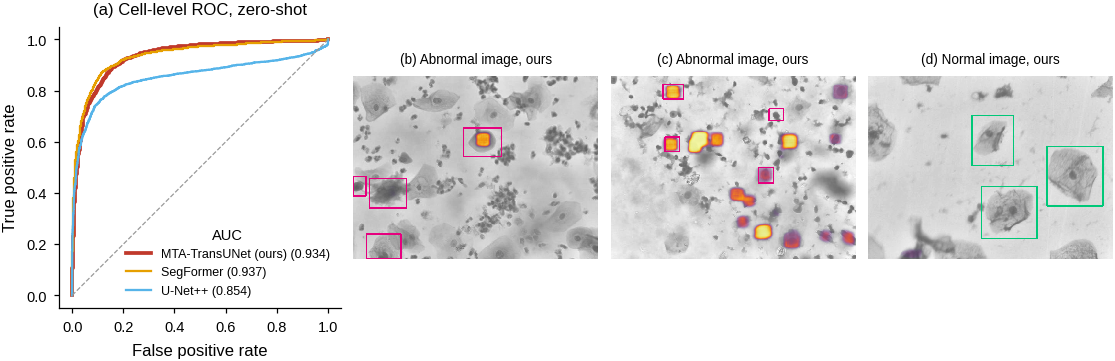

In [ ]:
# %%
# Mendeley LBC (Roboflow export) external test: data check, overlap check with our dataset, zero-shot on 3 models
import os, re, glob, json, shutil, zipfile, subprocess, gc, numpy as np, pandas as pd, cv2, torch
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from sklearn.metrics import roc_auc_score, roc_curve
try:
    import segmentation_models_pytorch as smp
except ImportError:
    subprocess.run(["pip", "install", "-q", "segmentation-models-pytorch"]); import segmentation_models_pytorch as smp

ROOT = os.environ.get("CERVIX_ROOT", "/content/gdrive/MyDrive/cervical")
if ROOT.startswith("/content/gdrive") and not os.path.exists("/content/gdrive/MyDrive"):
    from google.colab import drive; drive.mount("/content/gdrive")
RES = f"{ROOT}/results_q1_proposed"; CK, OUT, FIG = f"{RES}/checkpoints", f"{RES}/tables", f"{RES}/figures"
PARENT = os.path.dirname(ROOT)
MEN = os.environ.get("CERVIX_MEN_DRIVE") or next((p for p in glob.glob(f"{PARENT}/*") if os.path.basename(p).lower() == "mendeley-dataset"),
                                                   f"{PARENT}/Mendeley-dataset")
LOCAL = "/content/men" if os.path.exists("/content") else "/tmp/men"
IMG_H, IMG_W, SEED, N_BOOT, HAM = 384, 512, 42, 1000, 6
MODELS = {"MTA-TransUNet (ours)": "w_o_scSE_attention", "SegFormer": "SegFormer__MiT_B2", "U-Net++": "U_Net____R34"}
COL = {"MTA-TransUNet (ours)": "#C0392B", "SegFormer": "#E69F00", "U-Net++": "#56B4E9"}
OURS = "MTA-TransUNet (ours)"
DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu"); AMP = DEV.type == "cuda"
IMX = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
for d in (OUT, FIG):
    os.makedirs(d, exist_ok=True)

if not os.path.isdir(LOCAL):                                             # copy once per session (zip or folder)
    zips = glob.glob(f"{MEN}/*.zip")
    if zips:
        for z in zips:
            zipfile.ZipFile(z).extractall(LOCAL)
    else:
        shutil.copytree(MEN, LOCAL)


def cls_of(name):
    n = name.lower()
    return 1 if "abn" in n else 0 if "norm" in n else None


def stem(p):
    b = os.path.basename(p)
    return re.split(r"\.rf\.", b)[0] if ".rf." in b else os.path.splitext(b)[0]


BOX = {}                                                                 # image path -> list of (x1, y1, x2, y2, label) in pixels
for js in glob.glob(f"{LOCAL}/**/*.json", recursive=True):               # COCO
    try:
        c = json.load(open(js))
    except Exception:
        continue
    if not isinstance(c, dict) or "annotations" not in c:
        continue
    cm = {k["id"]: cls_of(k["name"]) for k in c["categories"]}; im = {i["id"]: os.path.join(os.path.dirname(js), i["file_name"]) for i in c["images"]}
    for p in im.values():
        BOX.setdefault(p, [])
    for a in c["annotations"]:
        if cm.get(a["category_id"]) is not None and a.get("bbox"):
            x, y, w, h = a["bbox"]; BOX[im[a["image_id"]]].append((x, y, x + w, y + h, cm[a["category_id"]]))
if not BOX:
    for yml in glob.glob(f"{LOCAL}/**/data.yaml", recursive=True):       # YOLO (boxes or polygons)
        import yaml
        nm = yaml.safe_load(open(yml))["names"]; nm = list(nm.values()) if isinstance(nm, dict) else nm
        for t in glob.glob(f"{os.path.dirname(yml)}/**/labels/*.txt", recursive=True):
            ip = next((q for e in IMX for q in [t.replace("/labels/", "/images/")[:-4] + e] if os.path.exists(q)), None)
            if ip is None:
                continue
            W, H = Image.open(ip).size; BOX[ip] = []
            for ln in open(t).read().split("\n"):
                v = ln.split()
                if len(v) < 5 or cls_of(nm[int(v[0])]) is None:
                    continue
                q = np.array(v[1:], float)
                if len(q) == 4:
                    cx, cy, w, h = q; x1, y1, x2, y2 = cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2
                else:
                    x1, y1, x2, y2 = q[0::2].min(), q[1::2].min(), q[0::2].max(), q[1::2].max()
                BOX[ip].append((x1 * W, y1 * H, x2 * W, y2 * H, cls_of(nm[int(v[0])])))
if not BOX:
    for x in glob.glob(f"{LOCAL}/**/*.xml", recursive=True):             # Pascal VOC
        r = ET.parse(x).getroot()
        ip = next((q for e in IMX for q in [x[:-4] + e] if os.path.exists(q)), None)
        if ip is None:
            continue
        BOX[ip] = [(*[float(o.find("bndbox").find(k).text) for k in ("xmin", "ymin", "xmax", "ymax")], cls_of(o.find("name").text))
                   for o in r.iter("object") if cls_of(o.find("name").text) is not None]
assert BOX, f"no COCO / YOLO / VOC annotations found under {MEN}"

seen, ITEMS = set(), []                                                  # one copy per source image (drops Roboflow augmented copies)
for p in sorted(BOX):
    s = stem(p)
    if s in seen or not os.path.exists(p) or not BOX[p]:
        continue
    seen.add(s); b = BOX[p]
    ITEMS.append(dict(path=p, id=s, boxes=b, label=int(any(k[4] == 1 for k in b)), size=Image.open(p).size))
SZ = pd.Series([f"{w}x{h}" for w, h in (i["size"] for i in ITEMS)]).value_counts()
print(f"annotated files: {len(BOX)} | unique source images with boxes: {len(ITEMS)} | image sizes: {SZ.head(3).to_dict()}")
if len(SZ) == 1 and SZ.index[0] in ("640x640", "416x416", "512x512"):
    print("WARNING: images were resized to a square by Roboflow; re-export at original size if possible")


def dhash(path, size=8):
    g = cv2.imread(path, cv2.IMREAD_REDUCED_GRAYSCALE_4)
    return None if g is None else np.packbits((cv2.resize(g, (size + 1, size), interpolation=cv2.INTER_AREA)[:, 1:] >
                                                cv2.resize(g, (size + 1, size), interpolation=cv2.INTER_AREA)[:, :-1]).ravel())


def hash_all(paths):
    with ThreadPoolExecutor(8) as ex:
        hs = list(ex.map(dhash, paths))
    k = [(p, h) for p, h in zip(paths, hs) if h is not None]
    return [p for p, _ in k], np.unpackbits(np.stack([h for _, h in k]), axis=1).astype(np.int32)


OWN = [p for s in ("train", "valid", "test") for p in glob.glob(f"{ROOT}/{s}/*") if p.lower().endswith(IMX)]
N0 = len(ITEMS); n_dup = 0
if OWN:
    _, A = hash_all(OWN); kb, B = hash_all([i["path"] for i in ITEMS])
    D = A.shape[1] - (A @ B.T + (1 - A) @ (1 - B).T); bad = {kb[j] for j in np.nonzero((D <= HAM).any(0))[0]}
    n_dup = len(bad); ITEMS = [i for i in ITEMS if i["path"] not in bad]
    print(f"overlap with our dataset ({len(OWN)} images): {n_dup} Mendeley images within Hamming <= {HAM}; excluded")
else:
    print(f"WARNING: our images not found under {ROOT}/train|valid|test; overlap check skipped")
NC = sum(len(i["boxes"]) for i in ITEMS); NA = sum(k[4] for i in ITEMS for k in i["boxes"])
T20a = pd.DataFrame([{"Source images with boxes": N0, "Duplicates of our data (excluded)": n_dup if OWN else "not checked",
                      "Test images": len(ITEMS), "Abnormal images": sum(i["label"] for i in ITEMS),
                      "Cells (boxes)": NC, "Abnormal cells": NA, "Normal cells": NC - NA, "Image size": SZ.index[0]}])
T20a.to_csv(f"{OUT}/table20a_mendeley_data.csv", index=False); print(T20a.to_string(index=False), "\n")

# %%
# Zero-shot: no retraining, no threshold tuning. Cell score = mean class probability inside each box (as SIPaKMeD).


def build(name):
    if name == OURS:
        class Net(torch.nn.Module):
            def __init__(self):
                super().__init__()
                self.net = smp.Unet("mit_b2", encoder_weights=None, classes=3, aux_params=dict(classes=1, dropout=0.2))
                self.segmentation_head = self.net.segmentation_head

            def forward(self, x):
                out = self.net(x)
                return out if self.training else out[0]
        return Net()
    if name == "SegFormer":
        return smp.Segformer("mit_b2", encoder_weights=None, classes=3)
    return smp.UnetPlusPlus("resnet34", encoder_weights=None, classes=3)


def load(name):
    m = build(name); m.load_state_dict(torch.load(f"{CK}/{MODELS[name]}.pt", map_location="cpu", weights_only=False)["model"])
    return m.to(DEV).eval()


MEAN, STD = np.array([0.485, 0.456, 0.406]) * 255, np.array([0.229, 0.224, 0.225]) * 255


def prep(it):
    W, H = it["size"]
    im = cv2.imread(it["path"], cv2.IMREAD_REDUCED_COLOR_2 if max(W, H) > 1600 else cv2.IMREAD_COLOR)
    lab = cv2.cvtColor(cv2.cvtColor(im, cv2.COLOR_BGR2RGB), cv2.COLOR_RGB2LAB)
    lab[..., 0] = cv2.createCLAHE(2.0, (8, 8)).apply(lab[..., 0])
    im = cv2.resize(cv2.cvtColor(lab, cv2.COLOR_LAB2RGB), (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)
    sx, sy = IMG_W / W, IMG_H / H
    bx = [(int(x1 * sx), int(y1 * sy), max(int(np.ceil(x2 * sx)), int(x1 * sx) + 1), max(int(np.ceil(y2 * sy)), int(y1 * sy) + 1), l)
          for x1, y1, x2, y2, l in it["boxes"]]
    return im, bx


@torch.no_grad()
def evaluate(model, items, name, keep=()):
    cells, imgs, ex = [], [], {}
    for it in items:
        im, bx = prep(it)
        x = torch.from_numpy(((im - MEAN) / STD).transpose(2, 0, 1)).float()[None].to(DEV)
        with torch.autocast(DEV.type, dtype=torch.float16, enabled=AMP):
            p = (model(x).float().softmax(1) + model(x.flip(-1)).float().softmax(1).flip(-1)
                 + model(x.flip(-2)).float().softmax(1).flip(-2))[0].cpu().numpy() / 3
        imgs.append(dict(model=name, image=it["id"], label=it["label"], score=float(np.percentile(p[2], 99.5))))
        fg = p.argmax(0) > 0
        for x1, y1, x2, y2, l in bx:
            mp = p[:, y1:y2, x1:x2].reshape(3, -1).mean(1)
            cells.append(dict(model=name, image=it["id"], y=l, p_abn=float(mp[2] / (mp[1] + mp[2] + 1e-8)), pred=int(mp[2] > mp[1]),
                              detected=bool(fg[y1:y2, x1:x2].mean() >= 0.25)))
        if it["id"] in keep:
            ex[it["id"]] = (im, p[2].astype(np.float16), bx)
        del x, p
    return pd.DataFrame(cells), pd.DataFrame(imgs), ex


def boot_auc(C, ims, draws):
    grp = C.groupby("image").indices; y, s = C.y.values, C.p_abn.values; out = []
    for b in draws:
        ix = np.concatenate([grp[ims[j]] for j in b if ims[j] in grp])
        out.append(roc_auc_score(y[ix], s[ix]) if 0 < y[ix].sum() < len(ix) else np.nan)
    return np.array(out)


def holm(p):
    p = np.asarray(p); o = np.argsort(p); adj = np.empty(len(p)); run = 0
    for k, i in enumerate(o):
        run = max(run, min(1.0, (len(p) - k) * p[i])); adj[i] = run
    return adj


def summary(C, I, ab):
    y, s, pr = C.y.values, C.p_abn.values, C.pred.values
    tp, tn = ((pr == 1) & (y == 1)).sum(), ((pr == 0) & (y == 0)).sum()
    fp, fn = ((pr == 1) & (y == 0)).sum(), ((pr == 0) & (y == 1)).sum()
    se, sp, pc = tp / max(tp + fn, 1), tn / max(tn + fp, 1), tp / max(tp + fp, 1)
    return {"Images": I.image.nunique(), "Cells": len(C), "Cell AUC": f"{roc_auc_score(y, s):.3f}",
            "AUC 95% CI": f"[{np.nanpercentile(ab, 2.5):.3f}, {np.nanpercentile(ab, 97.5):.3f}]",
            "Accuracy (%)": f"{100 * (tp + tn) / len(y):.2f}", "Balanced acc. (%)": f"{50 * (se + sp):.2f}",
            "Sensitivity (%)": f"{100 * se:.2f}", "Specificity (%)": f"{100 * sp:.2f}", "Precision (%)": f"{100 * pc:.2f}",
            "F1 (%)": f"{200 * pc * se / max(pc + se, 1e-8):.2f}", "Detection rate (%)": f"{100 * C.detected.mean():.2f}",
            "Image AUC": f"{roc_auc_score(I.label, I.score):.3f}" if I.label.nunique() == 2 else "n/a"}


rk = np.random.default_rng(SEED)
KEEP = [i["id"] for i in rk.permutation([i for i in ITEMS if i["label"] == 1])[:2]] + \
       [i["id"] for i in rk.permutation([i for i in ITEMS if i["label"] == 0])[:1]]
CC, II, EX = [], [], {}
for n in MODELS:                                                        # one model in memory at a time
    m = load(n); c_, i_, e_ = evaluate(m, ITEMS, n, keep=KEEP if n == OURS else ())
    CC.append(c_); II.append(i_); EX.update(e_); del m; gc.collect(); torch.cuda.empty_cache()
    print(f"{n}: {len(c_)} cells done")
CC, II = pd.concat(CC, ignore_index=True), pd.concat(II, ignore_index=True)
CC.to_csv(f"{OUT}/mendeley_zeroshot_cells.csv", index=False)
ims = sorted(CC.image.unique()); r = np.random.default_rng(SEED); draws = [r.integers(0, len(ims), len(ims)) for _ in range(N_BOOT)]
AB = {n: boot_auc(CC[CC.model == n], ims, draws) for n in MODELS}
T20 = pd.DataFrame([{"Model": n, **summary(CC[CC.model == n], II[II.model == n], AB[n])} for n in MODELS])
rows = []
for b in [n for n in MODELS if n != OURS]:
    d = AB[OURS] - AB[b]; d = d[~np.isnan(d)]
    obs = roc_auc_score(CC[CC.model == OURS].y, CC[CC.model == OURS].p_abn) - roc_auc_score(CC[CC.model == b].y, CC[CC.model == b].p_abn)
    rows.append({"Comparison": f"Ours vs {b}", "Δ cell AUC": f"{obs:+.3f}", "95% CI": f"[{np.percentile(d, 2.5):+.3f}, {np.percentile(d, 97.5):+.3f}]",
                 "p": max(min(1.0, 2 * min((d <= 0).mean(), (d >= 0).mean())), 1 / len(d))})
T21 = pd.DataFrame(rows); ph = holm(T21.p); T21["p (Holm)"] = [f"{v:.1e}" for v in ph]
T21["Sig."] = ["***" if v < 1e-3 else "**" if v < 1e-2 else "*" if v < 0.05 else "n.s." for v in ph]; T21 = T21.drop(columns="p")
T20.to_csv(f"{OUT}/table20_mendeley_zeroshot.csv", index=False); T21.to_csv(f"{OUT}/table21_mendeley_zeroshot_tests.csv", index=False)
for t in (T20, T21):
    print(t.to_string(index=False), "\n")

MM = 1 / 25.4
plt.rcParams.update({"font.size": 7, "axes.spines.top": False, "axes.spines.right": False, "pdf.fonttype": 42, "legend.frameon": False})
fig = plt.figure(figsize=(190 * MM, 62 * MM), constrained_layout=True); gs = fig.add_gridspec(1, 4, width_ratios=[1.15, 1, 1, 1])
ax = fig.add_subplot(gs[0, 0])
for n in MODELS:
    d = CC[CC.model == n]; f_, t_, _ = roc_curve(d.y, d.p_abn)
    ax.plot(f_, t_, color=COL[n], lw=1.8 if n == OURS else 1.1, label=f"{n} ({roc_auc_score(d.y, d.p_abn):.3f})")
ax.plot([0, 1], [0, 1], "--", color="0.6", lw=0.6); ax.set_aspect("equal")
ax.set(xlabel="False positive rate", ylabel="True positive rate", title="(a) Cell-level ROC, zero-shot"); ax.legend(title="AUC", loc="lower right", fontsize=6)
for k, key in enumerate([i for i in KEEP if i in EX]):
    im, pm, bx = EX[key]; pm = pm.astype(np.float32); a = np.clip(pm * 1.5, 0, 0.9)[..., None]
    g = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)[..., None] / 255 * 0.65 + 0.35
    ov = (np.clip((1 - a) * g + a * plt.cm.inferno(pm)[..., :3], 0, 1) * 255).astype(np.uint8).copy()
    for x1, y1, x2, y2, l in bx:
        cv2.rectangle(ov, (x1, y1), (x2 - 1, y2 - 1), (230, 0, 126) if l else (0, 200, 120), 2)
    ax = fig.add_subplot(gs[0, k + 1]); ax.imshow(ov); ax.axis("off")
    ax.set_title(f"({'bcd'[k]}) {'Abnormal' if any(b[4] for b in bx) else 'Normal'} image, ours", fontsize=6.5)
for e, dpi in (("pdf", None), ("png", 300), ("tiff", 600)):
    fig.savefig(f"{FIG}/Fig18_external_Mendeley_zeroshot.{e}", dpi=dpi, bbox_inches="tight",
                **({"pil_kwargs": {"compression": "tiff_lzw"}} if e == "tiff" else {}))
plt.show()

annotated files: 959 | unique source images with boxes: 959 | image sizes: {'640x640': 959}
overlap with our dataset (399 images): 0 Mendeley images within Hamming <= 6; excluded
 Source images with boxes  Duplicates of our data (excluded)  Test images  Abnormal images  Cells (boxes)  Abnormal cells  Normal cells Image size
                      959                                  0          959              351           4745            2320          2425    640x640 

MTA-TransUNet (ours): 4745 cells done
SegFormer: 4745 cells done
U-Net++: 4745 cells done
               Model  Images  Cells Cell AUC     AUC 95% CI Accuracy (%) Balanced acc. (%) Sensitivity (%) Specificity (%) Precision (%) F1 (%) Detection rate (%) Image AUC
MTA-TransUNet (ours)     959   4745    0.934 [0.923, 0.943]        80.67             80.33           64.57           96.08         94.04  76.57              24.28     0.881
           SegFormer     959   4745    0.937 [0.926, 0.947]        77.34             76.8

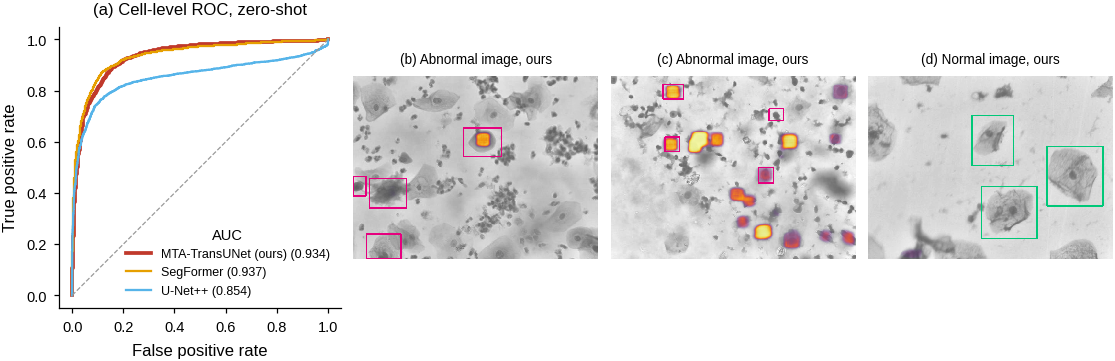

adaptation split: 192 training images, 767 test images
[MTA-TransUNet (ours)] epoch 1/15 loss 1.2939
[MTA-TransUNet (ours)] epoch 2/15 loss 0.7887
[MTA-TransUNet (ours)] epoch 3/15 loss 0.6858
[MTA-TransUNet (ours)] epoch 4/15 loss 0.6176
[MTA-TransUNet (ours)] epoch 5/15 loss 0.6240
[MTA-TransUNet (ours)] epoch 6/15 loss 0.5808
[MTA-TransUNet (ours)] epoch 7/15 loss 0.5522
[MTA-TransUNet (ours)] epoch 8/15 loss 0.4768
[MTA-TransUNet (ours)] epoch 9/15 loss 0.5152
[MTA-TransUNet (ours)] epoch 10/15 loss 0.4803
[MTA-TransUNet (ours)] epoch 11/15 loss 0.4749
[MTA-TransUNet (ours)] epoch 12/15 loss 0.4381
[MTA-TransUNet (ours)] epoch 13/15 loss 0.4570
[MTA-TransUNet (ours)] epoch 14/15 loss 0.4469
[MTA-TransUNet (ours)] epoch 15/15 loss 0.4084
[SegFormer] epoch 1/15 loss 1.1284
[SegFormer] epoch 2/15 loss 0.7474
[SegFormer] epoch 3/15 loss 0.6419
[SegFormer] epoch 4/15 loss 0.5960
[SegFormer] epoch 5/15 loss 0.5897
[SegFormer] epoch 6/15 loss 0.5457
[SegFormer] epoch 7/15 loss 0.5345
[Seg

In [ ]:
# %%
# Mendeley LBC (Roboflow export) external test: data check, overlap check with our dataset, zero-shot on 3 models
import os, re, glob, json, shutil, zipfile, subprocess, gc, numpy as np, pandas as pd, cv2, torch, torch.nn.functional as F
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from sklearn.metrics import roc_auc_score, roc_curve
try:
    import segmentation_models_pytorch as smp
except ImportError:
    subprocess.run(["pip", "install", "-q", "segmentation-models-pytorch"]); import segmentation_models_pytorch as smp

ROOT = os.environ.get("CERVIX_ROOT", "/content/gdrive/MyDrive/cervical")
if ROOT.startswith("/content/gdrive") and not os.path.exists("/content/gdrive/MyDrive"):
    from google.colab import drive; drive.mount("/content/gdrive")
RES = f"{ROOT}/results_q1_proposed"; CK, OUT, FIG = f"{RES}/checkpoints", f"{RES}/tables", f"{RES}/figures"
PARENT = os.path.dirname(ROOT)
MEN = os.environ.get("CERVIX_MEN_DRIVE") or next((p for p in glob.glob(f"{PARENT}/*") if os.path.basename(p).lower() == "mendeley-dataset"),
                                                   f"{PARENT}/Mendeley-dataset")
LOCAL = "/content/men" if os.path.exists("/content") else "/tmp/men"
IMG_H, IMG_W, SEED, N_BOOT, HAM = 384, 512, 42, 1000, 6
MODELS = {"MTA-TransUNet (ours)": "w_o_scSE_attention", "SegFormer": "SegFormer__MiT_B2", "U-Net++": "U_Net____R34"}
COL = {"MTA-TransUNet (ours)": "#C0392B", "SegFormer": "#E69F00", "U-Net++": "#56B4E9"}
OURS = "MTA-TransUNet (ours)"
DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu"); AMP = DEV.type == "cuda"
IMX = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
for d in (OUT, FIG):
    os.makedirs(d, exist_ok=True)

if not os.path.isdir(LOCAL):                                             # copy once per session (zip or folder)
    zips = glob.glob(f"{MEN}/*.zip")
    if zips:
        for z in zips:
            zipfile.ZipFile(z).extractall(LOCAL)
    else:
        shutil.copytree(MEN, LOCAL)


def cls_of(name):
    n = name.lower()
    return 1 if "abn" in n else 0 if "norm" in n else None


def stem(p):
    b = os.path.basename(p)
    return re.split(r"\.rf\.", b)[0] if ".rf." in b else os.path.splitext(b)[0]


BOX = {}                                                                 # image path -> list of (x1, y1, x2, y2, label) in pixels
for js in glob.glob(f"{LOCAL}/**/*.json", recursive=True):               # COCO
    try:
        c = json.load(open(js))
    except Exception:
        continue
    if not isinstance(c, dict) or "annotations" not in c:
        continue
    cm = {k["id"]: cls_of(k["name"]) for k in c["categories"]}; im = {i["id"]: os.path.join(os.path.dirname(js), i["file_name"]) for i in c["images"]}
    for p in im.values():
        BOX.setdefault(p, [])
    for a in c["annotations"]:
        if cm.get(a["category_id"]) is not None and a.get("bbox"):
            x, y, w, h = a["bbox"]; BOX[im[a["image_id"]]].append((x, y, x + w, y + h, cm[a["category_id"]]))
if not BOX:
    for yml in glob.glob(f"{LOCAL}/**/data.yaml", recursive=True):       # YOLO (boxes or polygons)
        import yaml
        nm = yaml.safe_load(open(yml))["names"]; nm = list(nm.values()) if isinstance(nm, dict) else nm
        for t in glob.glob(f"{os.path.dirname(yml)}/**/labels/*.txt", recursive=True):
            ip = next((q for e in IMX for q in [t.replace("/labels/", "/images/")[:-4] + e] if os.path.exists(q)), None)
            if ip is None:
                continue
            W, H = Image.open(ip).size; BOX[ip] = []
            for ln in open(t).read().split("\n"):
                v = ln.split()
                if len(v) < 5 or cls_of(nm[int(v[0])]) is None:
                    continue
                q = np.array(v[1:], float)
                if len(q) == 4:
                    cx, cy, w, h = q; x1, y1, x2, y2 = cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2
                else:
                    x1, y1, x2, y2 = q[0::2].min(), q[1::2].min(), q[0::2].max(), q[1::2].max()
                BOX[ip].append((x1 * W, y1 * H, x2 * W, y2 * H, cls_of(nm[int(v[0])])))
if not BOX:
    for x in glob.glob(f"{LOCAL}/**/*.xml", recursive=True):             # Pascal VOC
        r = ET.parse(x).getroot()
        ip = next((q for e in IMX for q in [x[:-4] + e] if os.path.exists(q)), None)
        if ip is None:
            continue
        BOX[ip] = [(*[float(o.find("bndbox").find(k).text) for k in ("xmin", "ymin", "xmax", "ymax")], cls_of(o.find("name").text))
                   for o in r.iter("object") if cls_of(o.find("name").text) is not None]
assert BOX, f"no COCO / YOLO / VOC annotations found under {MEN}"

seen, ITEMS = set(), []                                                  # one copy per source image (drops Roboflow augmented copies)
for p in sorted(BOX):
    s = stem(p)
    if s in seen or not os.path.exists(p) or not BOX[p]:
        continue
    seen.add(s); b = BOX[p]
    ITEMS.append(dict(path=p, id=s, boxes=b, label=int(any(k[4] == 1 for k in b)), size=Image.open(p).size))
SZ = pd.Series([f"{w}x{h}" for w, h in (i["size"] for i in ITEMS)]).value_counts()
print(f"annotated files: {len(BOX)} | unique source images with boxes: {len(ITEMS)} | image sizes: {SZ.head(3).to_dict()}")
if len(SZ) == 1 and SZ.index[0] in ("640x640", "416x416", "512x512"):
    print("WARNING: images were resized to a square by Roboflow; re-export at original size if possible")


def dhash(path, size=8):
    g = cv2.imread(path, cv2.IMREAD_REDUCED_GRAYSCALE_4)
    return None if g is None else np.packbits((cv2.resize(g, (size + 1, size), interpolation=cv2.INTER_AREA)[:, 1:] >
                                                cv2.resize(g, (size + 1, size), interpolation=cv2.INTER_AREA)[:, :-1]).ravel())


def hash_all(paths):
    with ThreadPoolExecutor(8) as ex:
        hs = list(ex.map(dhash, paths))
    k = [(p, h) for p, h in zip(paths, hs) if h is not None]
    return [p for p, _ in k], np.unpackbits(np.stack([h for _, h in k]), axis=1).astype(np.int32)


OWN = [p for s in ("train", "valid", "test") for p in glob.glob(f"{ROOT}/{s}/*") if p.lower().endswith(IMX)]
N0 = len(ITEMS); n_dup = 0
if OWN:
    _, A = hash_all(OWN); kb, B = hash_all([i["path"] for i in ITEMS])
    D = A.shape[1] - (A @ B.T + (1 - A) @ (1 - B).T); bad = {kb[j] for j in np.nonzero((D <= HAM).any(0))[0]}
    n_dup = len(bad); ITEMS = [i for i in ITEMS if i["path"] not in bad]
    print(f"overlap with our dataset ({len(OWN)} images): {n_dup} Mendeley images within Hamming <= {HAM}; excluded")
else:
    print(f"WARNING: our images not found under {ROOT}/train|valid|test; overlap check skipped")
NC = sum(len(i["boxes"]) for i in ITEMS); NA = sum(k[4] for i in ITEMS for k in i["boxes"])
T20a = pd.DataFrame([{"Source images with boxes": N0, "Duplicates of our data (excluded)": n_dup if OWN else "not checked",
                      "Test images": len(ITEMS), "Abnormal images": sum(i["label"] for i in ITEMS),
                      "Cells (boxes)": NC, "Abnormal cells": NA, "Normal cells": NC - NA, "Image size": SZ.index[0]}])
T20a.to_csv(f"{OUT}/table20a_mendeley_data.csv", index=False); print(T20a.to_string(index=False), "\n")

# Zero-shot: no retraining, no threshold tuning. Cell score = mean class probability inside each box (as SIPaKMeD).


def build(name):
    if name == OURS:
        class Net(torch.nn.Module):
            def __init__(self):
                super().__init__()
                self.net = smp.Unet("mit_b2", encoder_weights=None, classes=3, aux_params=dict(classes=1, dropout=0.2))
                self.segmentation_head = self.net.segmentation_head

            def forward(self, x):
                out = self.net(x)
                return out if self.training else out[0]
        return Net()
    if name == "SegFormer":
        return smp.Segformer("mit_b2", encoder_weights=None, classes=3)
    return smp.UnetPlusPlus("resnet34", encoder_weights=None, classes=3)


def load(name, path=None):
    m = build(name); m.load_state_dict(torch.load(path or f"{CK}/{MODELS[name]}.pt", map_location="cpu", weights_only=False)["model"])
    return m.to(DEV).eval()


MEAN, STD = np.array([0.485, 0.456, 0.406]) * 255, np.array([0.229, 0.224, 0.225]) * 255


def prep(it):
    W, H = it["size"]
    im = cv2.imread(it["path"], cv2.IMREAD_REDUCED_COLOR_2 if max(W, H) > 1600 else cv2.IMREAD_COLOR)
    lab = cv2.cvtColor(cv2.cvtColor(im, cv2.COLOR_BGR2RGB), cv2.COLOR_RGB2LAB)
    lab[..., 0] = cv2.createCLAHE(2.0, (8, 8)).apply(lab[..., 0])
    im = cv2.resize(cv2.cvtColor(lab, cv2.COLOR_LAB2RGB), (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)
    sx, sy = IMG_W / W, IMG_H / H
    bx = [(int(x1 * sx), int(y1 * sy), max(int(np.ceil(x2 * sx)), int(x1 * sx) + 1), max(int(np.ceil(y2 * sy)), int(y1 * sy) + 1), l)
          for x1, y1, x2, y2, l in it["boxes"]]
    return im, bx


@torch.no_grad()
def evaluate(model, items, name, keep=()):
    cells, imgs, ex = [], [], {}
    for it in items:
        im, bx = prep(it)
        x = torch.from_numpy(((im - MEAN) / STD).transpose(2, 0, 1)).float()[None].to(DEV)
        with torch.autocast(DEV.type, dtype=torch.float16, enabled=AMP):
            p = (model(x).float().softmax(1) + model(x.flip(-1)).float().softmax(1).flip(-1)
                 + model(x.flip(-2)).float().softmax(1).flip(-2))[0].cpu().numpy() / 3
        imgs.append(dict(model=name, image=it["id"], label=it["label"], score=float(np.percentile(p[2], 99.5))))
        fg = p.argmax(0) > 0
        for x1, y1, x2, y2, l in bx:
            mp = p[:, y1:y2, x1:x2].reshape(3, -1).mean(1)
            cells.append(dict(model=name, image=it["id"], y=l, p_abn=float(mp[2] / (mp[1] + mp[2] + 1e-8)), pred=int(mp[2] > mp[1]),
                              detected=bool(fg[y1:y2, x1:x2].mean() >= 0.25)))
        if it["id"] in keep:
            ex[it["id"]] = (im, p[2].astype(np.float16), bx)
        del x, p
    return pd.DataFrame(cells), pd.DataFrame(imgs), ex


def boot_auc(C, ims, draws):
    grp = C.groupby("image").indices; y, s = C.y.values, C.p_abn.values; out = []
    for b in draws:
        ix = np.concatenate([grp[ims[j]] for j in b if ims[j] in grp])
        out.append(roc_auc_score(y[ix], s[ix]) if 0 < y[ix].sum() < len(ix) else np.nan)
    return np.array(out)


def holm(p):
    p = np.asarray(p); o = np.argsort(p); adj = np.empty(len(p)); run = 0
    for k, i in enumerate(o):
        run = max(run, min(1.0, (len(p) - k) * p[i])); adj[i] = run
    return adj


def summary(C, I, ab):
    y, s, pr = C.y.values, C.p_abn.values, C.pred.values
    tp, tn = ((pr == 1) & (y == 1)).sum(), ((pr == 0) & (y == 0)).sum()
    fp, fn = ((pr == 1) & (y == 0)).sum(), ((pr == 0) & (y == 1)).sum()
    se, sp, pc = tp / max(tp + fn, 1), tn / max(tn + fp, 1), tp / max(tp + fp, 1)
    return {"Images": I.image.nunique(), "Cells": len(C), "Cell AUC": f"{roc_auc_score(y, s):.3f}",
            "AUC 95% CI": f"[{np.nanpercentile(ab, 2.5):.3f}, {np.nanpercentile(ab, 97.5):.3f}]",
            "Accuracy (%)": f"{100 * (tp + tn) / len(y):.2f}", "Balanced acc. (%)": f"{50 * (se + sp):.2f}",
            "Sensitivity (%)": f"{100 * se:.2f}", "Specificity (%)": f"{100 * sp:.2f}", "Precision (%)": f"{100 * pc:.2f}",
            "F1 (%)": f"{200 * pc * se / max(pc + se, 1e-8):.2f}", "Detection rate (%)": f"{100 * C.detected.mean():.2f}",
            "Image AUC": f"{roc_auc_score(I.label, I.score):.3f}" if I.label.nunique() == 2 else "n/a"}



# %%
rk = np.random.default_rng(SEED)
KEEP = [i["id"] for i in rk.permutation([i for i in ITEMS if i["label"] == 1])[:2]] + \
       [i["id"] for i in rk.permutation([i for i in ITEMS if i["label"] == 0])[:1]]
CC, II, EX = [], [], {}
for n in MODELS:                                                        # one model in memory at a time
    m = load(n); c_, i_, e_ = evaluate(m, ITEMS, n, keep=KEEP if n == OURS else ())
    CC.append(c_); II.append(i_); EX.update(e_); del m; gc.collect(); torch.cuda.empty_cache()
    print(f"{n}: {len(c_)} cells done")
CC, II = pd.concat(CC, ignore_index=True), pd.concat(II, ignore_index=True)
CC.to_csv(f"{OUT}/mendeley_zeroshot_cells.csv", index=False)
ims = sorted(CC.image.unique()); r = np.random.default_rng(SEED); draws = [r.integers(0, len(ims), len(ims)) for _ in range(N_BOOT)]
AB = {n: boot_auc(CC[CC.model == n], ims, draws) for n in MODELS}
T20 = pd.DataFrame([{"Model": n, **summary(CC[CC.model == n], II[II.model == n], AB[n])} for n in MODELS])
rows = []
for b in [n for n in MODELS if n != OURS]:
    d = AB[OURS] - AB[b]; d = d[~np.isnan(d)]
    obs = roc_auc_score(CC[CC.model == OURS].y, CC[CC.model == OURS].p_abn) - roc_auc_score(CC[CC.model == b].y, CC[CC.model == b].p_abn)
    rows.append({"Comparison": f"Ours vs {b}", "Δ cell AUC": f"{obs:+.3f}", "95% CI": f"[{np.percentile(d, 2.5):+.3f}, {np.percentile(d, 97.5):+.3f}]",
                 "p": max(min(1.0, 2 * min((d <= 0).mean(), (d >= 0).mean())), 1 / len(d))})
T21 = pd.DataFrame(rows); ph = holm(T21.p); T21["p (Holm)"] = [f"{v:.1e}" for v in ph]
T21["Sig."] = ["***" if v < 1e-3 else "**" if v < 1e-2 else "*" if v < 0.05 else "n.s." for v in ph]; T21 = T21.drop(columns="p")
T20.to_csv(f"{OUT}/table20_mendeley_zeroshot.csv", index=False); T21.to_csv(f"{OUT}/table21_mendeley_zeroshot_tests.csv", index=False)
for t in (T20, T21):
    print(t.to_string(index=False), "\n")

MM = 1 / 25.4
plt.rcParams.update({"font.size": 7, "axes.spines.top": False, "axes.spines.right": False, "pdf.fonttype": 42, "legend.frameon": False})
fig = plt.figure(figsize=(190 * MM, 62 * MM), constrained_layout=True); gs = fig.add_gridspec(1, 4, width_ratios=[1.15, 1, 1, 1])
ax = fig.add_subplot(gs[0, 0])
for n in MODELS:
    d = CC[CC.model == n]; f_, t_, _ = roc_curve(d.y, d.p_abn)
    ax.plot(f_, t_, color=COL[n], lw=1.8 if n == OURS else 1.1, label=f"{n} ({roc_auc_score(d.y, d.p_abn):.3f})")
ax.plot([0, 1], [0, 1], "--", color="0.6", lw=0.6); ax.set_aspect("equal")
ax.set(xlabel="False positive rate", ylabel="True positive rate", title="(a) Cell-level ROC, zero-shot"); ax.legend(title="AUC", loc="lower right", fontsize=6)
for k, key in enumerate([i for i in KEEP if i in EX]):
    im, pm, bx = EX[key]; pm = pm.astype(np.float32); a = np.clip(pm * 1.5, 0, 0.9)[..., None]
    g = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)[..., None] / 255 * 0.65 + 0.35
    ov = (np.clip((1 - a) * g + a * plt.cm.inferno(pm)[..., :3], 0, 1) * 255).astype(np.uint8).copy()
    for x1, y1, x2, y2, l in bx:
        cv2.rectangle(ov, (x1, y1), (x2 - 1, y2 - 1), (230, 0, 126) if l else (0, 200, 120), 2)
    ax = fig.add_subplot(gs[0, k + 1]); ax.imshow(ov); ax.axis("off")
    ax.set_title(f"({'bcd'[k]}) {'Abnormal' if any(b[4] for b in bx) else 'Normal'} image, ours", fontsize=6.5)
for e, dpi in (("pdf", None), ("png", 300), ("tiff", 600)):
    fig.savefig(f"{FIG}/Fig18_external_Mendeley_zeroshot.{e}", dpi=dpi, bbox_inches="tight",
                **({"pil_kwargs": {"compression": "tiff_lzw"}} if e == "tiff" else {}))
plt.show()

# %%
# Few-shot adaptation on Mendeley: fine-tune each model on 20% of images (stratified by image label), test on the other 80%.
# Box-supervised targets: inscribed ellipse per box (normal / abnormal), bright slide background = background, rest ignored.
# Same recipe for all models; checkpoints saved every epoch (resumable). Needs Cell 1 only; zero-shot scores read from Table 20 run.
ADAPT_FRAC, EPOCHS, BATCH, LR, IGN = 0.20, int(os.environ.get("MEN_EPOCHS", 15)), 4, 1e-4, 255
ZS = pd.read_csv(f"{OUT}/mendeley_zeroshot_cells.csv")
ra = np.random.default_rng(SEED); TR, TE = [], []
for l in (0, 1):
    g = [i for i in ITEMS if i["label"] == l]; o = ra.permutation(len(g)); k = max(1, int(round(ADAPT_FRAC * len(g))))
    TR += [g[j] for j in o[:k]]; TE += [g[j] for j in o[k:]]
print(f"adaptation split: {len(TR)} training images, {len(TE)} test images")


def target(it):
    im, bx = prep(it); g = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)
    lb = np.full(g.shape, IGN, np.uint8); t, _ = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU); lb[g > t] = 0
    for x1, y1, x2, y2, l in sorted(bx, key=lambda b: b[4]):          # abnormal drawn last (wins overlaps)
        cv2.ellipse(lb, ((x1 + x2) // 2, (y1 + y2) // 2), (max(1, (x2 - x1) // 2), max(1, (y2 - y1) // 2)), 0, 0, 360, 2 if l else 1, -1)
    return im, lb


TRAIN = [target(it) for it in TR]; YIMG = [it["label"] for it in TR]
freq = np.bincount(np.concatenate([l[l != IGN] for _, l in TRAIN]), minlength=3).astype(float); freq /= freq.sum()
CEW = torch.tensor(np.minimum((w := 1 / np.sqrt(freq + 1e-8)) / w.mean(), 10.0), dtype=torch.float32, device=DEV)


def loss_fn(out, y, yi):
    aux = None
    if isinstance(out, (tuple, list)):
        out, aux = out
    out = out.float(); ce = F.cross_entropy(out, y, weight=CEW, ignore_index=IGN)
    v = (y != IGN).unsqueeze(1).float(); pr = out.softmax(1) * v; oh = F.one_hot(y.clamp(max=2), 3).permute(0, 3, 1, 2).float() * v
    dice = (2 * (pr * oh).sum((0, 2, 3)) + 1) / (pr.sum((0, 2, 3)) + oh.sum((0, 2, 3)) + 1)
    l = ce + (1 - dice[1:].mean())
    return l + 0.2 * F.binary_cross_entropy_with_logits(aux.float(), yi[:, None]) if aux is not None else l


def to_t(im):
    return torch.from_numpy(((im - MEAN) / STD).transpose(2, 0, 1)).float()


def finetune(name):
    ck = f"{CK}/{MODELS[name]}_mendeley_adapt.pt"
    m = load(name); opt = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EPOCHS); scaler = torch.amp.GradScaler(DEV.type, enabled=AMP); ep0 = 0
    if os.path.exists(ck):
        st = torch.load(ck, map_location=DEV, weights_only=False)
        m.load_state_dict(st["model"]); opt.load_state_dict(st["opt"]); sch.load_state_dict(st["sch"]); ep0 = st["epoch"]
        print(f"[{name}] resumed at epoch {ep0}")
    g = torch.Generator().manual_seed(SEED); rng = np.random.default_rng(SEED + ep0)
    for ep in range(ep0, EPOCHS):
        m.train(); tot = 0.0
        for b in torch.randperm(len(TRAIN), generator=g).split(BATCH):
            xs, ys = [], []
            for i in b.tolist():
                im, lb = TRAIN[i]
                if rng.random() < 0.5:
                    im, lb = im[:, ::-1], lb[:, ::-1]
                if rng.random() < 0.5:
                    im, lb = im[::-1], lb[::-1]
                xs.append(to_t(np.ascontiguousarray(im))); ys.append(torch.from_numpy(np.ascontiguousarray(lb)).long())
            x, y = torch.stack(xs).to(DEV), torch.stack(ys).to(DEV)
            yi = torch.tensor([YIMG[i] for i in b.tolist()], dtype=torch.float32, device=DEV)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(DEV.type, dtype=torch.float16, enabled=AMP):
                loss = loss_fn(m(x), y, yi)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); tot += loss.item() * len(b)
        sch.step()
        torch.save({"model": m.state_dict(), "opt": opt.state_dict(), "sch": sch.state_dict(), "epoch": ep + 1}, ck + ".tmp"); os.replace(ck + ".tmp", ck)
        print(f"[{name}] epoch {ep + 1}/{EPOCHS} loss {tot / len(TRAIN):.4f}")
    del m, opt; gc.collect(); torch.cuda.empty_cache()
    return ck


AD_C, AD_I = [], []
for n in MODELS:
    ck = finetune(n); m = load(n, ck); c_, i_, _ = evaluate(m, TE, n); AD_C.append(c_); AD_I.append(i_)
    del m; gc.collect(); torch.cuda.empty_cache()
AD_C, AD_I = pd.concat(AD_C, ignore_index=True), pd.concat(AD_I, ignore_index=True)
AD_C.to_csv(f"{OUT}/mendeley_adapted_cells.csv", index=False)
te_ids = {it["id"] for it in TE}; ZT = ZS[ZS.image.astype(str).isin(te_ids)]
ims2 = sorted(AD_C.image.unique()); r2 = np.random.default_rng(SEED); draws2 = [r2.integers(0, len(ims2), len(ims2)) for _ in range(N_BOOT)]
ABA = {n: boot_auc(AD_C[AD_C.model == n], ims2, draws2) for n in MODELS}
rows = []
for n in MODELS:
    s = summary(AD_C[AD_C.model == n], AD_I[AD_I.model == n], ABA[n]); z = roc_auc_score(ZT[ZT.model == n].y, ZT[ZT.model == n].p_abn)
    rows.append({"Model": n, "Zero-shot cell AUC": f"{z:.3f}", "Adapted cell AUC": s["Cell AUC"], "AUC 95% CI": s["AUC 95% CI"],
                 "Δ AUC": f"{float(s['Cell AUC']) - z:+.3f}", **{k: s[k] for k in ("Balanced acc. (%)", "Sensitivity (%)", "Specificity (%)",
                                                                                   "F1 (%)", "Detection rate (%)", "Image AUC")}})
T22 = pd.DataFrame(rows); T22.to_csv(f"{OUT}/table22_mendeley_adapted.csv", index=False)
rows = []
for b in [n for n in MODELS if n != OURS]:
    d = ABA[OURS] - ABA[b]; d = d[~np.isnan(d)]
    obs = roc_auc_score(AD_C[AD_C.model == OURS].y, AD_C[AD_C.model == OURS].p_abn) - roc_auc_score(AD_C[AD_C.model == b].y, AD_C[AD_C.model == b].p_abn)
    rows.append({"Comparison": f"Ours vs {b}", "Δ cell AUC": f"{obs:+.3f}", "95% CI": f"[{np.percentile(d, 2.5):+.3f}, {np.percentile(d, 97.5):+.3f}]",
                 "p": max(min(1.0, 2 * min((d <= 0).mean(), (d >= 0).mean())), 1 / len(d))})
T23 = pd.DataFrame(rows); ph = holm(T23.p); T23["p (Holm)"] = [f"{v:.1e}" for v in ph]
T23["Sig."] = ["***" if v < 1e-3 else "**" if v < 1e-2 else "*" if v < 0.05 else "n.s." for v in ph]; T23 = T23.drop(columns="p")
T23.to_csv(f"{OUT}/table23_mendeley_adapted_tests.csv", index=False)
for t in (T22, T23):
    print(t.to_string(index=False), "\n")

MM = 1 / 25.4
plt.rcParams.update({"font.size": 7, "axes.spines.top": False, "axes.spines.right": False, "pdf.fonttype": 42, "legend.frameon": False})
fig, axs = plt.subplots(1, 2, figsize=(190 * MM, 72 * MM), constrained_layout=True)
ax = axs[0]
for n in MODELS:
    for C_, ls, tag in [(ZT, ":", "zero-shot"), (AD_C, "-", "adapted")]:
        d = C_[C_.model == n]; f_, t_, _ = roc_curve(d.y, d.p_abn)
        ax.plot(f_, t_, ls=ls, color=COL[n], lw=1.8 if n == OURS else 1.0, label=f"{n}, {tag} ({roc_auc_score(d.y, d.p_abn):.3f})")
ax.plot([0, 1], [0, 1], "--", color="0.7", lw=0.5); ax.set_aspect("equal")
ax.set(xlabel="False positive rate", ylabel="True positive rate", title=f"(a) Held-out {int(100 * (1 - ADAPT_FRAC))}%: before and after adaptation")
ax.legend(fontsize=5.5, loc="lower right")
ax = axs[1]; mets = ["Balanced acc. (%)", "Sensitivity (%)", "Specificity (%)", "F1 (%)"]; off = np.linspace(-0.27, 0.27, len(MODELS))
for k, n in enumerate(MODELS):
    v = [float(T22.loc[T22.Model == n, c].iloc[0]) for c in mets]
    bars = ax.bar(np.arange(len(mets)) + off[k], v, width=0.26, color=COL[n], edgecolor="black" if n == OURS else "none", lw=0.5, label=n)
    ax.bar_label(bars, fmt="%.0f", fontsize=5, padding=1)
ax.set_xticks(range(len(mets)), [c.replace(" (%)", "") for c in mets])
ax.set(ylabel="%", ylim=(0, 108), title="(b) After adaptation, held-out cells"); ax.legend(fontsize=6, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)
for e, dpi in (("pdf", None), ("png", 300), ("tiff", 600)):
    fig.savefig(f"{FIG}/Fig19_Mendeley_adaptation.{e}", dpi=dpi, bbox_inches="tight", **({"pil_kwargs": {"compression": "tiff_lzw"}} if e == "tiff" else {}))
plt.show()